<a name="indice"></a>
## 🎥 Índice APENAS para Apresentação – Aero Insight


-  [Introdução e Objetivo](#introducao)
-  [Dados e Fontes](#dados-e-fontes)
-  [Engenharia de Features](#engenharia-de-features)
-  [Pré-processamento](#pre-processamento)
-  [Modelagem](#modelagem)
-  [Avaliação](#avaliacao)
-  [Calibração](#calibracao)
-  [Artefato Final](#artefato-final)
-  [Conclusão](#conclusao)

### O indice do notebook do colab foi configurado e funciona !

#  Previsão de VOOS

<a name="introducao"></a>
## 1. Introdução e Objetivo
[⬆️ Índice](#indice)

A operação do transporte aéreo é fortemente influenciada por fatores temporais, geográficos, históricos e meteorológicos. Atrasos e cancelamentos de voos geram impactos relevantes para companhias aéreas, aeroportos e passageiros, resultando em custos operacionais adicionais, replanejamento de recursos e degradação da experiência do usuário.

Neste contexto, a capacidade de **antecipar o risco de atraso de um voo antes da sua execução** representa um diferencial operacional importante, permitindo a adoção de ações preventivas, como ajustes de malha aérea, alocação antecipada de equipes e comunicação proativa com passageiros.

O objetivo deste projeto é **desenvolver um modelo de Machine Learning capaz de prever a probabilidade de atraso de voos**, utilizando exclusivamente **informações disponíveis antes da decolagem**, evitando qualquer tipo de vazamento de informação. Para isso, é construído um pipeline completo que integra dados operacionais de voos, informações geográficas, variáveis temporais, histórico operacional e dados meteorológicos.

O projeto foi desenvolvido no contexto de um **hackathon de Data Science**, priorizando rigor técnico e clareza na comunicação dos resultados, de forma que o trabalho seja compreensível tanto para avaliadores técnicos quanto para públicos não especializados.



## 2. Contexto do Problema

A previsão de atrasos de voos é um desafio multifatorial que envolve condições climáticas, características operacionais, sazonalidade, localização geográfica e histórico recente de desempenho. Esses fatores interagem de forma não linear, dificultando abordagens baseadas apenas em regras fixas.

Do ponto de vista prático, decisões precisam ser tomadas **antes da decolagem**, o que exige o uso exclusivo de informações disponíveis no momento pré-voo, evitando qualquer vazamento de dados futuros.

Além disso, o problema apresenta forte **desbalanceamento de classes**, onde a maioria dos voos não atrasa, tornando essencial o uso de métricas e estratégias que priorizem a identificação de voos de maior risco.

O projeto considera operações comerciais do Brasil e dos Estados Unidos, aumentando a complexidade do problema, mas garantindo maior robustez e aplicabilidade do modelo em cenários reais.


<a name="dados-e-fontes"></a>
## 3. Fontes Oficiais de Dados
[⬆️ Índice](#indice)

Todos os dados utilizados neste projeto são provenientes **exclusivamente de fontes oficiais, públicas e reconhecidas por órgãos reguladores**, garantindo confiabilidade, padronização e rastreabilidade das informações.

- **ANAC (Agência Nacional de Aviação Civil – Brasil):**  
  Dados operacionais de voos comerciais no Brasil, incluindo horários previstos e realizados, aeroportos de origem e destino e companhias aéreas.

- **Bureau of Transportation Statistics (BTS – EUA):**  
  Base oficial vinculada ao *U.S. Department of Transportation (DOT)*, contendo dados padronizados de operações aéreas nos Estados Unidos, amplamente utilizada em estudos acadêmicos e industriais.

- **ERA5 – ECMWF:**  
  Base oficial de reanálise meteorológica mantida pelo *European Centre for Medium-Range Weather Forecasts*, utilizada para obtenção de variáveis climáticas com resolução horária.

- **OurAirports:**  
  Base pública amplamente utilizada para informações geográficas de aeroportos (latitude, longitude, país e região), permitindo a integração espacial dos dados.

O uso exclusivo de fontes oficiais garante que o modelo seja **reprodutível, auditável e aderente a padrões reais de operação aérea**.



## 4. Visão Geral do Pipeline

O pipeline deste projeto foi estruturado de forma **modular, escalável e temporalmente consistente**, seguindo boas práticas de Engenharia de Dados e Machine Learning.

O fluxo completo do projeto é composto pelas seguintes etapas:

1. **Construção do dataset de voos** a partir de fontes oficiais (ANAC e BTS), aplicando o mesmo esquema de variáveis e regras de negócio.
2. **Padronização e unificação** dos dados em um único formato, garantindo consistência entre países e bases regulatórias distintas.
3. **Enriquecimento geográfico** dos aeroportos de origem, incorporando latitude, longitude, país e estado/região.
4. **Enriquecimento climático** com dados meteorológicos do ERA5, utilizando janelas temporais de 1h e 3h antes do voo.
5. **Enriquecimento temporal e de calendário**, incluindo variáveis de data, horário, finais de semana e feriados regionais.
6. **Criação de histórico operacional**, calculando taxas móveis de atraso (rolling 30 dias) por rota, aeroporto e companhia aérea.
7. **Consolidação e diagnóstico do dataset final**, com validações de qualidade, domínio e consistência temporal.
8. **Modelagem preditiva**, respeitando separação temporal entre treino e teste.
9. **Persistência do artefato final**, permitindo reutilização e inferência futura.

Todas as transformações foram realizadas **exclusivamente com informações disponíveis antes do voo**, evitando qualquer forma de vazamento de informação.


In [124]:
# ==============================
# Ambiente e Sistema
# ==============================
import os
import sys
import time
import gc
from pathlib import Path

# ==============================
# Computação e Dados
# ==============================
import numpy as np
import pandas as pd

# ==============================
# Leitura e Escrita de Dados
# ==============================
import pyarrow as pa
import pyarrow.parquet as pq

# ==============================
# Progresso e Utilidades
# ==============================
from tqdm import tqdm
from tqdm.auto import tqdm

# ==============================
# Monitoramento de Memória
# ==============================
import psutil

# ==============================
# Datas e Calendário
# ==============================
import holidays

# ==============================
# Machine Learning - Pré-processamento e Modelos
# ==============================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV


# ==============================
# Métricas e Avaliação
# ==============================
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

# ==============================
# Diagnóstico Estatístico
# ==============================
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ==============================
# Visualização
# ==============================
import matplotlib.pyplot as plt

# ==============================
# Persistência de Modelos
# ==============================
import joblib

# ==============================
# Google Colab (se aplicável)
# ==============================
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 5. Construção do Dataset de Voos (ANAC + BTS)

Nesta etapa é realizada a construção do dataset base de voos a partir de **duas fontes regulatórias oficiais**:

- **ANAC (Brasil)**  
- **Bureau of Transportation Statistics – BTS (Estados Unidos)**

O objetivo é criar um **esquema único e padronizado de dados**, garantindo que ambas as bases representem o mesmo conceito operacional de voo.

As transformações realizadas nesta etapa seguem três princípios fundamentais:

- Utilizar apenas informações disponíveis **antes da realização do voo**
- Aplicar as **mesmas regras de negócio** para ambas as fontes
- Produzir um dataset **compatível e unificável** para as etapas seguintes


Abrindo um relatorio da ANAC - 01-2021

In [2]:
BASE_URL = "https://github.com/JessePMelo/FlightOnTime-Previs-o-de-Atrasos-de-Voos/releases/download/Data_FlightOnTime_v1/"
arquivo = "anac_vra_2021_01.csv"
url = BASE_URL + arquivo


df = pd.read_csv(
    url,
    sep=";",
    encoding="utf-8",
    header=1,
    low_memory=False
)

df.head()

,ICAO Empresa Aérea,Número Voo,Código Autorização (DI),Código Tipo Linha,ICAO Aeródromo Origem,ICAO Aeródromo Destino,Partida Prevista,Partida Real,Chegada Prevista,Chegada Real,Situação Voo,Código Justificativa
0,TAM,3447,0,N,SBGR,SBFI,2021-01-09 20:25:00,2021-01-09 20:21:00,2021-01-09 22:05:00,2021-01-09 21:56:00,REALIZADO,NaN
1,TAM,3447,0,N,SBGR,SBFI,2021-01-10 20:25:00,2021-01-10 20:24:00,2021-01-10 22:05:00,2021-01-10 21:55:00,REALIZADO,NaN
2,TAM,3447,0,N,SBGR,SBFI,2021-01-11 20:25:00,2021-01-11 20:27:00,2021-01-11 22:05:00,2021-01-11 21:58:00,REALIZADO,NaN
3,TAM,3447,0,N,SBGR,SBFI,2021-01-12 20:25:00,2021-01-12 20:24:00,2021-01-12 22:05:00,2021-01-12 21:58:00,REALIZADO,NaN
4,TAM,3447,0,N,SBGR,SBFI,2021-01-13 20:25:00,2021-01-13 20:16:00,2021-01-13 22:05:00,2021-01-13 21:48:00,REALIZADO,NaN


### Padronização e Validação Inicial — ANAC

Após a aplicação das regras de limpeza e engenharia de features, o dataset da ANAC passa por validações estruturais, garantindo consistência de tipos, ausência de vazamentos e definição correta da variável alvo.


In [3]:
df["Partida Prevista"] = pd.to_datetime(df["Partida Prevista"], errors="coerce")
df["Partida Real"] = pd.to_datetime(df["Partida Real"], errors="coerce")

/tmp/ipython-input-2990940821.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Partida Real"] = pd.to_datetime(df["Partida Real"], errors="coerce")


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60351 entries, 0 to 60350
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ICAO Empresa Aérea       60351 non-null  object        
 1   Número Voo               60351 non-null  object        
 2   Código Autorização (DI)  60351 non-null  object        
 3   Código Tipo Linha        60351 non-null  object        
 4   ICAO Aeródromo Origem    60351 non-null  object        
 5   ICAO Aeródromo Destino   60351 non-null  object        
 6   Partida Prevista         58415 non-null  datetime64[ns]
 7   Partida Real             58232 non-null  datetime64[ns]
 8   Chegada Prevista         58415 non-null  object        
 9   Chegada Real             58232 non-null  object        
 10  Situação Voo             60351 non-null  object        
 11  Código Justificativa     0 non-null      float64       
dtypes: datetime64[ns](2), float64(1)

REMOVER VOOS CANCELADOS

In [5]:
df["Situação Voo"] = df["Situação Voo"].astype(str).str.upper().str.strip()

VALID_STATUS = ["REALIZADO"]

df = df[df["Situação Voo"].isin(VALID_STATUS)].copy()


Remover linhas sem datas essenciais

In [6]:
df = df.dropna(subset=["Partida Prevista", "Partida Real"]).copy()

Criar DATA EXATA do voo

In [7]:
df["flight_date"] = df["Partida Prevista"].dt.date

Criar DATA EXATA do voo

In [8]:
df["flight_date"] = df["Partida Prevista"].dt.date

#### Criar FEATURES

hora prevista (0 - 23)

In [9]:
df["scheduled_hour"] = df["Partida Prevista"].dt.hour

dia da semana (0=Mon - 6=Sun)

In [10]:
df["day_of_week"] = df["Partida Prevista"].dt.dayofweek

mês do ano (1 - 12)

In [11]:
df["month"] = df["Partida Prevista"].dt.month

posição da semana no mês (1 - 5)

In [12]:
df["week_of_month"] = ((df["Partida Prevista"].dt.day - 1) // 7 + 1)

fim de semana

In [13]:
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

faixa horária (bucket)

In [14]:
def hour_bucket(h: int) -> int:
    if h < 6:
        return 0  # madrugada
    elif h < 12:
        return 1  # manhã
    elif h < 18:
        return 2  # tarde
    else:
        return 3  # noite

df["hour_bucket"] = df["scheduled_hour"].apply(hour_bucket)

rota (origem_destino)

In [15]:
df["route"] = (
    df["ICAO Aeródromo Origem"].astype(str)
    + "_"
    + df["ICAO Aeródromo Destino"].astype(str)
)

horário de pico (geral)

In [16]:
df["is_peak_hour"] = df["scheduled_hour"].isin(
    [6, 7, 8, 9, 17, 18, 19, 20]
).astype(int)


pico da manhã

In [17]:
df["is_morning_peak"] = df["scheduled_hour"].isin([6, 7, 8, 9]).astype(int)

pico da tarde/noite

In [18]:
df["is_evening_peak"] = df["scheduled_hour"].isin([17, 18, 19, 20]).astype(int)

Blindagem final de features

In [19]:
df = df.dropna(
    subset=[
        "flight_date",
        "scheduled_hour",
        "day_of_week",
        "month",
        "week_of_month",
        "is_weekend",
        "hour_bucket",
        "route",
        "is_peak_hour",
        "is_morning_peak",
        "is_evening_peak",
    ]
).copy()

garantir tipos inteiros

In [20]:
cols_int = [
    "scheduled_hour",
    "day_of_week",
    "month",
    "week_of_month",
    "is_weekend",
    "hour_bucket",
    "is_peak_hour",
    "is_morning_peak",
    "is_evening_peak",
]
for c in cols_int:
    df[c] = df[c].astype(int)


TARGET: atraso (PADRÃO INTERNACIONAL: >= 15 minutos)

In [21]:
df["delay_minutes"] = (
    (df["Partida Real"] - df["Partida Prevista"])
    .dt.total_seconds() / 60
)

blindagem

In [22]:
df["delay_minutes"] = pd.to_numeric(df["delay_minutes"], errors="coerce")
df = df.dropna(subset=["delay_minutes"]).copy()


delayed = 1 se atraso >= 15 min

In [23]:
df["delayed"] = (df["delay_minutes"] >= 15).astype(int)

remove coluna de atraso contínuo (evitar vazamento)

In [24]:
df = df.drop(columns=["delay_minutes"])

Renomear colunas

In [25]:
df = df.rename(columns={
    "ICAO Empresa Aérea": "airline",
    "ICAO Aeródromo Origem": "origin",
    "ICAO Aeródromo Destino": "destination"
})

Normalização de texto

In [26]:
for col in ["airline", "origin", "destination", "route"]:
    df[col] = df[col].astype(str).str.strip().str.upper()


Dataset FINAL

In [27]:
df_anac_2021_01 = df[
    [
        "flight_date",
        "airline",
        "origin",
        "destination",
        "route",
        "scheduled_hour",
        "hour_bucket",
        "is_peak_hour",
        "is_morning_peak",
        "is_evening_peak",
        "day_of_week",
        "is_weekend",
        "week_of_month",
        "month",
        "delayed",
    ]
].copy()

Checagens finais

In [28]:
print("\nNaNs por coluna:")
print(df_anac_2021_01.isna().sum())

print("\nDistribuição do target (delayed):")
print(df_anac_2021_01["delayed"].value_counts())



NaNs por coluna:
flight_date        0
airline            0
origin             0
destination        0
route              0
scheduled_hour     0
hour_bucket        0
is_peak_hour       0
is_morning_peak    0
is_evening_peak    0
day_of_week        0
is_weekend         0
week_of_month      0
month              0
delayed            0
dtype: int64

Distribuição do target (delayed):
delayed
0    50296
1     6000
Name: count, dtype: int64


In [29]:
df_anac_2021_01.nunique()

,0
flight_date,32
airline,57
origin,170
destination,173
route,1062
scheduled_hour,24
hour_bucket,4
is_peak_hour,2
is_morning_peak,2
is_evening_peak,2


### Padronização e Validação Inicial — BTS

Após a aplicação das regras de limpeza e engenharia de features, o dataset da ANAC passa por validações estruturais, garantindo consistência de tipos, ausência de vazamentos e definição correta da variável alvo.


In [30]:
BASE_URL = "https://github.com/JessePMelo/FlightOnTime-Previs-o-de-Atrasos-de-Voos/releases/download/Data_FlightOnTime_v1/"
arquivo = "bts_ontime_2021_01.csv"
url = BASE_URL + arquivo

In [31]:
df = pd.read_csv(
    url,
    sep=",",
    encoding="utf-8",
    low_memory=False
)

Visão geral do DataSet

In [32]:
df.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
0,2021,1,1,2,6,2021-01-02,9E,20363,9E,N337PQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021,1,1,3,7,2021-01-03,9E,20363,9E,N607LR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,1,1,4,1,2021-01-04,9E,20363,9E,N602LR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,1,1,7,4,2021-01-07,9E,20363,9E,N295PQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,1,1,8,5,2021-01-08,9E,20363,9E,N324PQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


REMOVER VOOS CANCELADOS

In [33]:
df["Cancelled"] = pd.to_numeric(df["Cancelled"], errors="coerce")
df = df.dropna(subset=["Cancelled"]).copy()
df = df[df["Cancelled"] == 0].copy()

Converter DATA do voo

In [34]:
df["FlightDate"] = pd.to_datetime(df["FlightDate"], errors="coerce")
df = df.dropna(subset=["FlightDate"]).copy()

#### Criar FEATURES

DATA EXATA

In [35]:
df["flight_date"] = df["FlightDate"].dt.date

Criar FEATURES

scheduled_hour (CRSDepTime vem como HHMM)

In [36]:
df["CRSDepTime"] = pd.to_numeric(df["CRSDepTime"], errors="coerce")
df = df.dropna(subset=["CRSDepTime"]).copy()

df["scheduled_hour"] = (df["CRSDepTime"] // 100)
df = df[df["scheduled_hour"].between(0, 23)].copy()
df["scheduled_hour"] = df["scheduled_hour"].astype(int)

day_of_week

In [37]:
df["DayOfWeek"] = pd.to_numeric(df["DayOfWeek"], errors="coerce")
df = df.dropna(subset=["DayOfWeek"]).copy()
df["day_of_week"] = df["DayOfWeek"] - 1
df = df[df["day_of_week"].between(0, 6)].copy()
df["day_of_week"] = df["day_of_week"].astype(int)

month

In [38]:
df["month"] = df["FlightDate"].dt.month.astype(int)

week_of_month (1 - 5)

In [39]:
df["week_of_month"] = ((df["FlightDate"].dt.day - 1) // 7 + 1).astype(int)

fim de semana

In [40]:
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

faixa horária

In [41]:
def hour_bucket(h: int) -> int:
    if h < 6:
        return 0  # madrugada
    elif h < 12:
        return 1  # manhã
    elif h < 18:
        return 2  # tarde
    else:
        return 3  # noite

df["hour_bucket"] = df["scheduled_hour"].apply(hour_bucket).astype(int)

rota

In [42]:
df["route"] = df["Origin"].astype(str) + "_" + df["Dest"].astype(str)

horários de pico

In [43]:
df["is_peak_hour"] = df["scheduled_hour"].isin([6, 7, 8, 9, 17, 18, 19, 20]).astype(int)
df["is_morning_peak"] = df["scheduled_hour"].isin([6, 7, 8, 9]).astype(int)
df["is_evening_peak"] = df["scheduled_hour"].isin([17, 18, 19, 20]).astype(int)


Blindagem final de features

In [44]:
df = df.dropna(
    subset=[
        "flight_date",
        "Reporting_Airline",
        "Origin",
        "Dest",
        "scheduled_hour",
        "day_of_week",
        "month",
        "week_of_month",
        "is_weekend",
        "hour_bucket",
        "route",
        "is_peak_hour",
        "is_morning_peak",
        "is_evening_peak",
    ]
).copy()


garantir tipos inteiros

In [45]:
cols_int = [
    "scheduled_hour",
    "day_of_week",
    "month",
    "week_of_month",
    "is_weekend",
    "hour_bucket",
    "is_peak_hour",
    "is_morning_peak",
    "is_evening_peak",
]
for c in cols_int:
    df[c] = df[c].astype(int)


TARGET: ATRASO (>= 15 min)

In [46]:
df["DepDel15"] = pd.to_numeric(df["DepDel15"], errors="coerce")
df = df.dropna(subset=["DepDel15"]).copy()

# blindagem: manter só 0/1
df = df[df["DepDel15"].isin([0, 1])].copy()
df["delayed"] = df["DepDel15"].astype(int)

 Renomear colunas

In [47]:
df = df.rename(columns={
    "Reporting_Airline": "airline",
    "Origin": "origin",
    "Dest": "destination"
})

Normalização de texto

In [48]:
for col in ["airline", "origin", "destination", "route"]:
    df[col] = df[col].astype(str).str.strip().str.upper()


Dataset FINAL

In [49]:
df_bts_2021_01 = df[
    [
        "flight_date",
        "airline",
        "origin",
        "destination",
        "route",
        "scheduled_hour",
        "hour_bucket",
        "is_peak_hour",
        "is_morning_peak",
        "is_evening_peak",
        "day_of_week",
        "is_weekend",
        "week_of_month",
        "month",
        "delayed",
    ]
].copy()

Checagens finais

In [50]:
print("\nNaNs por coluna (deve ser tudo 0):")
print(df_bts_2021_01.isna().sum())

print("\nDistribuição do target (delayed):")
print(df_bts_2021_01["delayed"].value_counts())




NaNs por coluna (deve ser tudo 0):
flight_date        0
airline            0
origin             0
destination        0
route              0
scheduled_hour     0
hour_bucket        0
is_peak_hour       0
is_morning_peak    0
is_evening_peak    0
day_of_week        0
is_weekend         0
week_of_month      0
month              0
delayed            0
dtype: int64

Distribuição do target (delayed):
delayed
0    327237
1     30544
Name: count, dtype: int64


In [51]:
df_bts_2021_01.nunique()

,0
flight_date,31
airline,17
origin,357
destination,357
route,5046
scheduled_hour,24
hour_bucket,4
is_peak_hour,2
is_morning_peak,2
is_evening_peak,2


<a name="engenharia-de-features"></a>
### Comparação estrutural dos conjuntos de dados (ANAC x BTS)
[⬆️ Índice](#indice)


In [52]:
df_bts_2021_01.info()

<class 'pandas.core.frame.DataFrame'>
Index: 357781 entries, 0 to 361427
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   flight_date      357781 non-null  object
 1   airline          357781 non-null  object
 2   origin           357781 non-null  object
 3   destination      357781 non-null  object
 4   route            357781 non-null  object
 5   scheduled_hour   357781 non-null  int64 
 6   hour_bucket      357781 non-null  int64 
 7   is_peak_hour     357781 non-null  int64 
 8   is_morning_peak  357781 non-null  int64 
 9   is_evening_peak  357781 non-null  int64 
 10  day_of_week      357781 non-null  int64 
 11  is_weekend       357781 non-null  int64 
 12  week_of_month    357781 non-null  int64 
 13  month            357781 non-null  int64 
 14  delayed          357781 non-null  int64 
dtypes: int64(10), object(5)
memory usage: 43.7+ MB


In [53]:
df_anac_2021_01.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56296 entries, 0 to 60350
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   flight_date      56296 non-null  object
 1   airline          56296 non-null  object
 2   origin           56296 non-null  object
 3   destination      56296 non-null  object
 4   route            56296 non-null  object
 5   scheduled_hour   56296 non-null  int64 
 6   hour_bucket      56296 non-null  int64 
 7   is_peak_hour     56296 non-null  int64 
 8   is_morning_peak  56296 non-null  int64 
 9   is_evening_peak  56296 non-null  int64 
 10  day_of_week      56296 non-null  int64 
 11  is_weekend       56296 non-null  int64 
 12  week_of_month    56296 non-null  int64 
 13  month            56296 non-null  int64 
 14  delayed          56296 non-null  int64 
dtypes: int64(10), object(5)
memory usage: 6.9+ MB


### Unificação e padronização dos dados da ANAC (ETL em escala)

Nesta etapa é realizado o processamento em larga escala dos dados da ANAC, abrangendo múltiplos meses e anos, com o objetivo de construir um conjunto de dados padronizado e compatível com a base da BTS.

O pipeline implementado aplica o mesmo processo de ETL previamente validado, garantindo consistência entre as fontes. Cada arquivo mensal é carregado individualmente, transformado para extrair apenas informações disponíveis antes do voo, e convertido para um esquema comum de colunas.

A escrita incremental do dataset final permite o processamento eficiente de grandes volumes de dados, reduzindo o consumo de memória e aumentando a robustez da execução. Ao final do processo, obtém-se um arquivo único contendo os dados consolidados da ANAC, pronto para ser unificado com as demais fontes e utilizado nas etapas de modelagem.



***Devido a pandemia e para melhor performance o split temporal vai de 2023 até 2025***

In [54]:
#removendo restrição de exibição de colunas
pd.set_option("display.max_columns", None)

# ============================================================
# CONFIG (mesmo padrão BTS)
# ============================================================
BASE_URL = "https://github.com/JessePMelo/FlightOnTime-Previs-o-de-Atrasos-de-Voos/releases/download/Data_FlightOnTime_v1/"

anos = [2023, 2024, 2025]
meses = range(1, 13)

# Saída incremental (igual BTS)
OUT_CSV = "df_anac_full_2021_01_2025_09.csv"

# Colunas finais (MESMO PADRÃO ANAC/BTS)
COLS_FINAL = [
    "flight_date",        # ← DATA EXATA DO VOO
    "airline",
    "origin",
    "destination",
    "route",
    "scheduled_hour",
    "hour_bucket",
    "is_peak_hour",
    "is_morning_peak",
    "is_evening_peak",
    "day_of_week",
    "is_weekend",
    "week_of_month",
    "month",
    "delayed",
]

# ============================================================
# FUNÇÃO AUXILIAR
# ============================================================
def hour_bucket(h: int) -> int:
    if h < 6:
        return 0  # madrugada
    elif h < 12:
        return 1  # manhã
    elif h < 18:
        return 2  # tarde
    else:
        return 3  # noite


def processar_anac_mes(url: str) -> pd.DataFrame:
    """
    ANAC (1 mês) → retorna SOMENTE COLS_FINAL
    (cópia fiel do pipeline validado, com flight_date incluído)
    """

    # ============================================================
    # 1) Carregar dados (ANAC exige header=1)
    # ============================================================
    df = pd.read_csv(
        url,
        sep=";",
        encoding="utf-8",
        header=1,
        low_memory=False
    )

    # ============================================================
    # 2) Converter datas (garantir datetime)
    # ============================================================
    df["Partida Prevista"] = pd.to_datetime(df["Partida Prevista"], errors="coerce")
    df["Partida Real"] = pd.to_datetime(df["Partida Real"], errors="coerce")

    # remover linhas sem datas essenciais
    df = df.dropna(subset=["Partida Prevista", "Partida Real"]).copy()

    # ============================================================
    # 2.1) DATA EXATA DO VOO (pré-voo)
    # ============================================================
    df["flight_date"] = df["Partida Prevista"].dt.date

    # ============================================================
    # 3) Criar FEATURES (somente pré-voo)
    # ============================================================
    df["scheduled_hour"] = df["Partida Prevista"].dt.hour
    df["day_of_week"] = df["Partida Prevista"].dt.dayofweek
    df["month"] = df["Partida Prevista"].dt.month
    df["week_of_month"] = ((df["Partida Prevista"].dt.day - 1) // 7 + 1)

    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    df["hour_bucket"] = df["scheduled_hour"].apply(hour_bucket)

    df["route"] = (
        df["ICAO Aeródromo Origem"].astype(str)
        + "_"
        + df["ICAO Aeródromo Destino"].astype(str)
    )

    df["is_peak_hour"] = df["scheduled_hour"].isin([6, 7, 8, 9, 17, 18, 19, 20]).astype(int)
    df["is_morning_peak"] = df["scheduled_hour"].isin([6, 7, 8, 9]).astype(int)
    df["is_evening_peak"] = df["scheduled_hour"].isin([17, 18, 19, 20]).astype(int)

    # ============================================================
    # 4) Blindagem final de features
    # ============================================================
    df = df.dropna(
        subset=[
            "flight_date",
            "scheduled_hour",
            "day_of_week",
            "month",
            "week_of_month",
            "is_weekend",
            "hour_bucket",
            "route",
            "is_peak_hour",
            "is_morning_peak",
            "is_evening_peak",
        ]
    ).copy()

    cols_int = [
        "scheduled_hour",
        "day_of_week",
        "month",
        "week_of_month",
        "is_weekend",
        "hour_bucket",
        "is_peak_hour",
        "is_morning_peak",
        "is_evening_peak",
    ]
    for c in cols_int:
        df[c] = df[c].astype(int)

    # ============================================================
    # 5) TARGET: atraso (>= 15 minutos)
    # ============================================================
    df["delay_minutes"] = (
        (df["Partida Real"] - df["Partida Prevista"])
        .dt.total_seconds() / 60
    )

    df["delay_minutes"] = pd.to_numeric(df["delay_minutes"], errors="coerce")
    df = df.dropna(subset=["delay_minutes"]).copy()

    df["delayed"] = (df["delay_minutes"] >= 15).astype(int)

    # remove delay_minutes (evitar vazamento)
    df = df.drop(columns=["delay_minutes"])

    # ============================================================
    # 6) Renomear colunas (padrão BTS)
    # ============================================================
    df = df.rename(columns={
        "ICAO Empresa Aérea": "airline",
        "ICAO Aeródromo Origem": "origin",
        "ICAO Aeródromo Destino": "destination"
    })

    # ============================================================
    # 7) Normalização de texto
    # ============================================================
    for col in ["airline", "origin", "destination", "route"]:
        df[col] = df[col].astype(str).str.strip().str.upper()

    # ============================================================
    # 8) Retornar somente colunas finais
    # ============================================================
    return df[COLS_FINAL].copy()


# ============================================================
# GERAR LISTA DE ARQUIVOS (2021_01 → 2025_09)
# ============================================================
arquivos = []
for ano in anos:
    for mes in meses:
        if ano == 2025 and mes > 9:
            break
        arquivos.append(f"anac_vra_{ano}_{mes:02d}.csv")

print(f"Total de arquivos ANAC para processar: {len(arquivos)}")
print(f"Saída incremental: {OUT_CSV}")

# ============================================================
# LOOP COM ESCRITA INCREMENTAL
# ============================================================
erros = []
primeiro = True  # controla header no CSV final

for nome_arquivo in tqdm(arquivos, desc="Processando ANAC (2021_01 → 2025_09)"):
    url = BASE_URL + nome_arquivo

    try:
        df_mes = processar_anac_mes(url)

        df_mes.to_csv(
            OUT_CSV,
            mode="w" if primeiro else "a",
            header=primeiro,
            index=False
        )
        primeiro = False

        del df_mes  # libera RAM

    except Exception as e:
        erros.append((nome_arquivo, str(e)))

# ============================================================
# RELATÓRIO FINAL
# ============================================================
print("\n✅ ANAC final salvo em:", OUT_CSV)

if erros:
    print(f"\n⚠️ Arquivos com erro: {len(erros)}")
    for item in erros[:5]:
        print(item)
else:
    print("\n✅ Nenhum erro nos arquivos.")

print("\nPrévia do arquivo final (5 linhas):")
print(pd.read_csv(OUT_CSV, nrows=5))


Total de arquivos ANAC para processar: 33
Saída incremental: df_anac_full_2021_01_2025_09.csv


Processando ANAC (2021_01 → 2025_09):   0%|          | 0/33 [00:00<?, ?it/s]

/tmp/ipython-input-3712699258.py:68: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Partida Prevista"] = pd.to_datetime(df["Partida Prevista"], errors="coerce")



✅ ANAC final salvo em: df_anac_full_2021_01_2025_09.csv

✅ Nenhum erro nos arquivos.

Prévia do arquivo final (5 linhas):
  flight_date airline origin destination      route  scheduled_hour  \
0  2023-01-01     AAL   KMIA        SBGR  KMIA_SBGR               0   
1  2023-01-02     AAL   KMIA        SBGR  KMIA_SBGR               0   
2  2023-01-03     AAL   KMIA        SBGR  KMIA_SBGR               0   
3  2023-01-04     AAL   KMIA        SBGR  KMIA_SBGR               0   
4  2023-01-05     AAL   KMIA        SBGR  KMIA_SBGR               0   

   hour_bucket  is_peak_hour  is_morning_peak  is_evening_peak  day_of_week  \
0            0             0                0                0            6   
1            0             0                0                0            0   
2            0             0                0                0            1   
3            0             0                0                0            2   
4            0             0                0          

### Unificação e padronização dos dados da BTS (ETL em escala)

Nesta etapa é realizado o processamento em larga escala dos dados provenientes da **Bureau of Transportation Statistics (BTS)**, abrangendo múltiplos meses e anos, com o objetivo de construir um conjunto de dados padronizado e compatível com a base da ANAC.

O pipeline aplica um processo de ETL consistente, garantindo que as variáveis extraídas da BTS sigam o mesmo esquema de colunas utilizado para os dados da ANAC. São consideradas apenas informações disponíveis antes da realização do voo, evitando vazamento de informação para o modelo.

Durante o processamento, voos cancelados são removidos, uma vez que o foco do projeto é a previsão de atrasos. A variável alvo `delayed` é definida com base no indicador `DepDel15`, seguindo o padrão internacional de atraso igual ou superior a 15 minutos.

A escrita incremental do dataset final permite o processamento eficiente de grandes volumes de dados, reduzindo o consumo de memória e garantindo maior robustez na execução. Ao final, obtém-se um arquivo consolidado da BTS, pronto para ser unificado com as demais fontes e utilizado nas etapas de modelagem.


In [55]:
BASE_URL = "https://github.com/JessePMelo/FlightOnTime-Previs-o-de-Atrasos-de-Voos/releases/download/Data_FlightOnTime_v1/"

anos = [2023, 2024, 2025]
meses = range(1, 13)

# Saída final (um CSV único, montado aos poucos)
OUT_CSV = "df_bts_full_2021_01_2025_09.csv"

# Colunas finais (MESMO PADRÃO ANAC)
COLS_FINAL = [
    "flight_date",        # ← DATA EXATA DO VOO
    "airline",
    "origin",
    "destination",
    "route",
    "scheduled_hour",
    "hour_bucket",
    "is_peak_hour",
    "is_morning_peak",
    "is_evening_peak",
    "day_of_week",
    "is_weekend",
    "week_of_month",
    "month",
    "delayed",
]

# Ler só colunas necessárias (economiza RAM/tempo)
USECOLS = [
    "Reporting_Airline",
    "Origin",
    "Dest",
    "Cancelled",
    "CRSDepTime",
    "DayOfWeek",
    "FlightDate",
    "DepDel15",
]

# ============================================================
# FUNÇÃO AUXILIAR
# ============================================================
def hour_bucket(h: int) -> int:
    if h < 6:
        return 0
    elif h < 12:
        return 1
    elif h < 18:
        return 2
    else:
        return 3


def processar_bts_mes(url: str) -> pd.DataFrame:
    """
    Processa 1 CSV mensal do BTS e devolve apenas COLS_FINAL
    (pré-voo + target delayed >= 15 min).
    """

    # ============================================================
    # 1) Ler só colunas necessárias
    # ============================================================
    df = pd.read_csv(
        url,
        sep=",",
        encoding="utf-8",
        low_memory=False,
        usecols=USECOLS
    )

    # ============================================================
    # 2) Remover cancelados (cancelado ≠ atraso)
    # ============================================================
    df["Cancelled"] = pd.to_numeric(df["Cancelled"], errors="coerce")
    df = df.dropna(subset=["Cancelled"]).copy()
    df = df[df["Cancelled"] == 0].copy()

    # ============================================================
    # 3) Converter DATA do voo (pré-voo)
    # ============================================================
    df["FlightDate"] = pd.to_datetime(df["FlightDate"], errors="coerce")
    df = df.dropna(subset=["FlightDate"]).copy()

    # DATA EXATA DO VOO (somente o DIA)
    df["flight_date"] = df["FlightDate"].dt.date

    # ============================================================
    # 4) scheduled_hour (CRSDepTime = HHMM)
    # ============================================================
    df["CRSDepTime"] = pd.to_numeric(df["CRSDepTime"], errors="coerce")
    df = df.dropna(subset=["CRSDepTime"]).copy()

    df["scheduled_hour"] = (df["CRSDepTime"] // 100)
    df = df[df["scheduled_hour"].between(0, 23)].copy()
    df["scheduled_hour"] = df["scheduled_hour"].astype(int)

    # ============================================================
    # 5) day_of_week (1..7 -> 0..6)
    # ============================================================
    df["DayOfWeek"] = pd.to_numeric(df["DayOfWeek"], errors="coerce")
    df = df.dropna(subset=["DayOfWeek"]).copy()

    df["day_of_week"] = df["DayOfWeek"] - 1
    df = df[df["day_of_week"].between(0, 6)].copy()
    df["day_of_week"] = df["day_of_week"].astype(int)

    # ============================================================
    # 6) month + week_of_month
    # ============================================================
    df["month"] = df["FlightDate"].dt.month.astype(int)
    df["week_of_month"] = ((df["FlightDate"].dt.day - 1) // 7 + 1).astype(int)

    # ============================================================
    # 7) fim de semana
    # ============================================================
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

    # ============================================================
    # 8) hour_bucket
    # ============================================================
    df["hour_bucket"] = df["scheduled_hour"].apply(hour_bucket).astype(int)

    # ============================================================
    # 9) route + picos
    # ============================================================
    df["route"] = df["Origin"].astype(str) + "_" + df["Dest"].astype(str)

    df["is_peak_hour"] = df["scheduled_hour"].isin(
        [6, 7, 8, 9, 17, 18, 19, 20]
    ).astype(int)

    df["is_morning_peak"] = df["scheduled_hour"].isin([6, 7, 8, 9]).astype(int)
    df["is_evening_peak"] = df["scheduled_hour"].isin([17, 18, 19, 20]).astype(int)

    # ============================================================
    # 10) TARGET delayed (>=15 min) — padrão internacional
    # ============================================================
    df["DepDel15"] = pd.to_numeric(df["DepDel15"], errors="coerce")
    df = df.dropna(subset=["DepDel15"]).copy()
    df = df[df["DepDel15"].isin([0, 1])].copy()
    df["delayed"] = df["DepDel15"].astype(int)

    # ============================================================
    # 11) Renomear (padrão ANAC)
    # ============================================================
    df = df.rename(columns={
        "Reporting_Airline": "airline",
        "Origin": "origin",
        "Dest": "destination",
    })

    # ============================================================
    # 12) Normalização de texto
    # ============================================================
    for col in ["airline", "origin", "destination", "route"]:
        df[col] = df[col].astype(str).str.strip().str.upper()

    # ============================================================
    # 13) Blindagem final + retorno
    # ============================================================
    df = df.dropna(
        subset=[
            "flight_date",
            "airline",
            "origin",
            "destination",
            "route",
            "scheduled_hour",
            "day_of_week",
            "month",
            "week_of_month",
            "is_weekend",
            "hour_bucket",
            "is_peak_hour",
            "is_morning_peak",
            "is_evening_peak",
            "delayed",
        ]
    ).copy()

    return df[COLS_FINAL].copy()


# ============================================================
# GERAR LISTA DE ARQUIVOS
# ============================================================
arquivos = []
for ano in anos:
    for mes in meses:
        if ano == 2025 and mes > 9:
            break
        arquivos.append(f"bts_ontime_{ano}_{mes:02d}.csv")

print(f"Total de arquivos BTS para processar: {len(arquivos)}")
print(f"Saída incremental: {OUT_CSV}")

# ============================================================
# LOOP COM ESCRITA INCREMENTAL
# ============================================================
erros = []
primeiro = True  # controla header no CSV final

for nome_arquivo in tqdm(arquivos, desc="Processando BTS (2021_01 → 2025_09)"):
    url = BASE_URL + nome_arquivo

    try:
        df_mes = processar_bts_mes(url)

        df_mes.to_csv(
            OUT_CSV,
            mode="w" if primeiro else "a",
            header=primeiro,
            index=False
        )
        primeiro = False

        del df_mes  # libera RAM

    except Exception as e:
        erros.append((nome_arquivo, str(e)))

# ============================================================
# RELATÓRIO FINAL
# ============================================================
print("\n✅ BTS final salvo em:", OUT_CSV)

if erros:
    print(f"\n⚠️ Arquivos com erro: {len(erros)}")
    print("Exemplos (até 5):")
    for item in erros[:5]:
        print(item)
else:
    print("\n✅ Nenhum erro nos arquivos.")

print("\nPrévia do arquivo final (5 linhas):")
print(pd.read_csv(OUT_CSV, nrows=5))


Total de arquivos BTS para processar: 33
Saída incremental: df_bts_full_2021_01_2025_09.csv


Processando BTS (2021_01 → 2025_09):   0%|          | 0/33 [00:00<?, ?it/s]


✅ BTS final salvo em: df_bts_full_2021_01_2025_09.csv

✅ Nenhum erro nos arquivos.

Prévia do arquivo final (5 linhas):
  flight_date airline origin destination    route  scheduled_hour  \
0  2023-01-02      9E    BDL         LGA  BDL_LGA               8   
1  2023-01-03      9E    BDL         LGA  BDL_LGA               8   
2  2023-01-04      9E    BDL         LGA  BDL_LGA               8   
3  2023-01-05      9E    BDL         LGA  BDL_LGA               8   
4  2023-01-06      9E    BDL         LGA  BDL_LGA               8   

   hour_bucket  is_peak_hour  is_morning_peak  is_evening_peak  day_of_week  \
0            1             1                1                0            0   
1            1             1                1                0            1   
2            1             1                1                0            2   
3            1             1                1                0            3   
4            1             1                1                0       

### Unificação final e persistência do dataset (ANAC + BTS)

Nesta etapa é realizada a unificação definitiva dos dados provenientes da ANAC e da BTS, consolidando ambas as fontes em um único conjunto de dados padronizado.

Devido ao grande volume de registros, a leitura dos arquivos CSV é feita de forma incremental, utilizando processamento em *chunks*, o que permite a execução do processo sem exceder os limites de memória do ambiente. Durante a unificação, é mantido exatamente o mesmo esquema de colunas para ambas as bases, garantindo consistência estrutural.

O dataset final é salvo no formato **Parquet**, que oferece melhor desempenho de leitura, compressão eficiente e maior adequação para análises em larga escala e aplicações de Machine Learning. Essa escolha facilita o uso posterior dos dados nas etapas de modelagem e inferência.


In [56]:
# ============================================================
# UNIFICAÇÃO FINAL: ANAC + BTS → PARQUET (SEM ESTOURAR RAM)
# - Lê os 2 CSVs finais em CHUNKS
# - Mantém exatamente o MESMO padrão de colunas
# - Barra de progresso geral + barra por dataset
# - Salva diretamente em Parquet

ANAC_CSV = "df_anac_full_2021_01_2025_09.csv"
BTS_CSV  = "df_bts_full_2021_01_2025_09.csv"

OUT_PARQUET = "df_full_anac_bts_2021_01_2025_09.parquet"

CHUNK_SIZE = 300_000  # seguro para Colab

# COLUNAS FINAIS (PADRÃO ÚNICO ANAC + BTS)
COLS_FINAL = [
    "flight_date",        # ← DATA EXATA DO VOO
    "airline",
    "origin",
    "destination",
    "route",
    "scheduled_hour",
    "hour_bucket",
    "is_peak_hour",
    "is_morning_peak",
    "is_evening_peak",
    "day_of_week",
    "is_weekend",
    "week_of_month",
    "month",
    "delayed",
]

# ============================================================
# FUNÇÃO: CSV → PARQUET (INCREMENTAL)
# ============================================================
def csv_to_parquet_incremental(csv_path, parquet_writer=None):

    # contar chunks (para barra correta)
    total_chunks = sum(
        1 for _ in pd.read_csv(csv_path, chunksize=CHUNK_SIZE)
    )

    reader = pd.read_csv(
        csv_path,
        usecols=COLS_FINAL,
        chunksize=CHUNK_SIZE,
        low_memory=False
    )

    for chunk in tqdm(
        reader,
        total=total_chunks,
        desc=f"Processando {os.path.basename(csv_path)}",
        leave=False
    ):
        table = pa.Table.from_pandas(
            chunk,
            preserve_index=False
        )

        if parquet_writer is None:
            parquet_writer = pq.ParquetWriter(
                OUT_PARQUET,
                table.schema,
                compression="snappy"
            )

        parquet_writer.write_table(table)

        # libera RAM imediatamente
        del chunk, table

    return parquet_writer


# ============================================================
# EXECUÇÃO
# ============================================================
if os.path.exists(OUT_PARQUET):
    os.remove(OUT_PARQUET)

writer = None

datasets = [
    ("ANAC", ANAC_CSV),
    ("BTS", BTS_CSV),
]

# barra de progresso GERAL
for nome, csv_path in tqdm(
    datasets,
    desc="Progresso geral (ANAC + BTS)",
    total=len(datasets)
):
    writer = csv_to_parquet_incremental(csv_path, writer)

# fechar parquet corretamente
writer.close()

print("\n✅ Unificação concluída com sucesso!")
print(f"📦 Arquivo gerado: {OUT_PARQUET}")


Progresso geral (ANAC + BTS):   0%|          | 0/2 [00:00<?, ?it/s]

Processando df_anac_full_2021_01_2025_09.csv:   0%|          | 0/9 [00:00<?, ?it/s]

Processando df_bts_full_2021_01_2025_09.csv:   0%|          | 0/64 [00:00<?, ?it/s]


✅ Unificação concluída com sucesso!
📦 Arquivo gerado: df_full_anac_bts_2021_01_2025_09.parquet


Checkpoint para não ter que abrir e processar tudo sempre

In [57]:
BASE_URL = "https://github.com/JessePMelo/FlightOnTime-Previs-o-de-Atrasos-de-Voos/releases/download/Processed_FlightOnTime_v1/"
arquivo = "df_full_anac_bts_2021_01_2025_09.parquet"
url = BASE_URL + arquivo
df_voos = pd.read_parquet(url)

### Carregamento do dataset final para análise e modelagem

Após a etapa de unificação e persistência dos dados, o dataset consolidado é carregado a partir do arquivo Parquet gerado. Essa abordagem garante uma leitura mais eficiente e prepara os dados para as etapas de análise exploratória e modelagem preditiva.

Nesta fase, é realizada a conversão da coluna de data do voo para o formato adequado, assegurando consistência temporal e facilitando futuras operações relacionadas a filtros e agregações.


In [58]:
BASE_URL = "https://github.com/JessePMelo/FlightOnTime-Previs-o-de-Atrasos-de-Voos/releases/download/Processed_FlightOnTime_v1/"
arquivo = "df_full_anac_bts_2021_01_2025_09.parquet"
url = BASE_URL + arquivo
df_voos = pd.read_parquet(url)

## 6. Enriquecimento Geográfico

Nesta etapa, o dataset de voos é enriquecido com informações geográficas dos aeroportos de origem, especificamente **latitude e longitude**.

Os dados geográficos são obtidos a partir da base pública **OurAirports**, que fornece mapeamentos oficiais para códigos **ICAO** e **IATA**. Como o dataset de voos utiliza ambos os padrões, é construída uma estrutura unificada que permite localizar aeroportos independentemente do tipo de código utilizado.

O objetivo deste enriquecimento é permitir:
- Integração posterior com dados meteorológicos
- Análises espaciais e regionais
- Maior contexto operacional para o modelo


### Construção do mapeamento geográfico de aeroportos

In [59]:
url = (
    "https://github.com/"
    "JessePMelo/FlightOnTime-Previs-o-de-Atrasos-de-Voos/"
    "releases/download/"
    "Processed_FlightOnTime_v1/"
    "airports.csv"
)

# Ler base OurAirports
airports = pd.read_csv(url)

# ICAO -> lat/lon
icao_map = (
    airports
    .dropna(subset=["ident", "latitude_deg", "longitude_deg"])
    [["ident", "latitude_deg", "longitude_deg"]]
    .rename(columns={
        "ident": "airport_code",
        "latitude_deg": "latitude",
        "longitude_deg": "longitude"
    })
)

# IATA -> lat/lon
iata_map = (
    airports
    .dropna(subset=["iata_code", "latitude_deg", "longitude_deg"])
    [["iata_code", "latitude_deg", "longitude_deg"]]
    .rename(columns={
        "iata_code": "airport_code",
        "latitude_deg": "latitude",
        "longitude_deg": "longitude"
    })
)

# Unificação ICAO + IATA
geo_map = (
    pd.concat([icao_map, iata_map], ignore_index=True)
    .drop_duplicates("airport_code")
    .reset_index(drop=True)
)


### Estrutura de lookup geográfico

O mapeamento geográfico é convertido em uma estrutura de dicionário para permitir consultas rápidas (*lookup O(1)*) durante o pipeline de dados, garantindo eficiência mesmo em grande volume.


In [60]:
# Dicionário para lookup O(1)
geo_map_dict = (
    geo_map
    .set_index("airport_code")[["latitude", "longitude"]]
    .to_dict("index")
)

missing_airports = set()

def get_lat_lon(airport_code: str):
    loc = geo_map_dict.get(airport_code)

    if loc is None:
        missing_airports.add(airport_code)
        return None, None

    return float(loc["latitude"]), float(loc["longitude"])


Catalogo geolocalização.

In [61]:
mapa = pd.read_csv(
    "/content/drive/MyDrive/Datasets Hackaton/data_lake/geollicalização_lat_lon_codigo_aeroporto.csv"
)

mapa = mapa.rename(columns={
    "airport_code": "origin"
})

mapa = mapa.drop_duplicates("origin")


In [62]:
df_voos = df_voos.merge(
    mapa,
    how="left",
    on="origin"
)


In [63]:
df_voos[["latitude", "longitude"]].isna().mean().mul(100)

,0
latitude,1.281259
longitude,1.281259


Ao final desta etapa, o projeto dispõe de um mapeamento geográfico padronizado e reutilizável, que será utilizado nas próximas fases de enriquecimento climático e regional, sem necessidade de reprocessamento.


## 7. Enriquecimento Climático (ERA5)

Nesta etapa, o dataset de voos é enriquecido com informações meteorológicas provenientes do **ERA5**, base oficial de reanálise climática mantida pelo **ECMWF** e amplamente utilizada por órgãos governamentais e pela indústria da aviação.

As variáveis climáticas são associadas aos voos com base em:
- Localização geográfica do aeroporto de origem (latitude e longitude)
- Horário programado de partida do voo

São consideradas apenas informações climáticas **anteriores ao voo**, garantindo coerência temporal e evitando vazamento de informação para o modelo.


### Definição das janelas temporais de análise climática

Para capturar o impacto das condições meteorológicas recentes na operação aérea, são definidas janelas de **1 hora** e **3 horas** antes do horário programado de partida do voo.

Essas janelas permitem avaliar tanto efeitos imediatos quanto condições acumuladas, mantendo o alinhamento com o momento real de tomada de decisão operacional.


In [64]:
df_clima_base = (
    df_voos[['origin','flight_date','scheduled_hour']]
    .rename(columns={'origin':'airport_code'})
    .copy()
)


garantindo tipo certo para manipulação posterior

In [65]:

df_clima_base["flight_date"] = pd.to_datetime(
    df_clima_base["flight_date"],
    errors="coerce"
)

df_clima_base["scheduled_hour"] = (
    pd.to_numeric(df_clima_base["scheduled_hour"], errors="coerce")
    .astype("Int64")
)


df_clima_base["flight_datetime"] = (
    df_clima_base["flight_date"]
    + pd.to_timedelta(df_clima_base["scheduled_hour"], unit="h")
)


Criando coluna flight_datetime garantindo tipo certo

In [66]:
df_clima_base["flight_datetime"] = (
    df_clima_base["flight_date"]
    + pd.to_timedelta(df_clima_base["scheduled_hour"], unit="h")
)


garantindo valores unicos para não ter duplicado no df(menos trabalho)

In [67]:
df_clima_keys = (
    df_clima_base
    .drop_duplicates()
    .reset_index(drop=True)
)


criando culuna ano-mes

In [68]:

df_clima_keys["year_month"] = (
    df_clima_keys["flight_datetime"]
    .dt.to_period("M")
    .astype(str)
)


### Associação espacial para dados meteorológicos

As coordenadas geográficas dos aeroportos são associadas às chaves climáticas por meio do mapeamento geográfico previamente construído. Essa etapa permite localizar cada voo no espaço e viabilizar a extração das variáveis meteorológicas correspondentes.


In [69]:
df_clima_keys[["latitude", "longitude"]] = (
    df_clima_keys["airport_code"]
    .astype(str)
    .apply(lambda code: pd.Series(get_lat_lon(code)))
)


### Preparação e leitura dos dados ERA5

Os dados meteorológicos do ERA5 são disponibilizados no formato NetCDF, organizados por período mensal. Para garantir eficiência e escalabilidade, os arquivos são processados de forma incremental, sendo carregados apenas quando necessários.


In [70]:
!pip install --upgrade netCDF4 h5netcdf xarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.1 MB/s eta 0:00:00
  Attempting uninstall: h5netcdf
    Found existing installation: h5netcdf 1.7.3
    Uninstalling h5netcdf-1.7.3:
      Successfully uninstalled h5netcdf-1.7.3


In [71]:
# Bibliotecas necessárias para NetCDF / ERA5
import xarray as xr
from pathlib import Path
import os


BASE_ERA5_PATH = Path("/content/drive/MyDrive/Datasets Hackaton/data_lake/era5")


# ============================================================
# Função para abrir arquivos ERA5 de um mês específico
# ============================================================

def abrir_era5(pasta_mes: Path):
    """
    Abre os arquivos ERA5 de um mês e retorna:
    - Dataset de variáveis instantâneas
    - Dataset de variáveis acumuladas
    """

    pasta_mes = Path(pasta_mes)

    instant_file = pasta_mes / "data_stream-oper_stepType-instant.nc"
    accum_file   = pasta_mes / "data_stream-oper_stepType-accum.nc"

    if not instant_file.exists() or not accum_file.exists():
        raise FileNotFoundError(f"Arquivos ERA5 não encontrados em {pasta_mes}")

    ds_inst = xr.open_dataset(
        instant_file,
        engine="netcdf4"
    ).rename({"valid_time": "time"})

    ds_acc = xr.open_dataset(
        accum_file,
        engine="netcdf4"
    ).rename({"valid_time": "time"})

    return ds_inst, ds_acc


Criação de janela temporal para dados do clima

In [72]:

df_clima_keys["window_1h_start"] = (
    df_clima_keys["flight_datetime"] - pd.Timedelta(hours=1)
)

df_clima_keys["window_3h_start"] = (
    df_clima_keys["flight_datetime"] - pd.Timedelta(hours=3)
)


### Extração e agregação das variáveis meteorológicas

As variáveis climáticas são extraídas a partir do ponto geográfico mais próximo ao aeroporto e agregadas dentro das janelas temporais definidas. Para cada janela, são calculadas estatísticas representativas, convertendo dados climáticos multidimensionais em features tabulares adequadas para modelos de Machine Learning.


In [73]:

def extrair_clima_1h_3h(
    ds_inst,
    ds_acc,
    lat,
    lon,
    flight_datetime,
    window_1h_start,
    window_3h_start
):
    """
    Extrai variáveis climáticas do ERA5 em janelas de 1h e 3h antes do voo.
    Retorna um dicionário de features numéricas.
    """

    def _extrair_janela(ds_inst, ds_acc, lat, lon, t_ini, t_fim, sufixo):
        # Seleção espacial (ponto mais próximo)
        inst_p = ds_inst.sel(latitude=lat, longitude=lon, method="nearest")
        acc_p  = ds_acc.sel(latitude=lat, longitude=lon, method="nearest")

        # Seleção temporal
        inst_w = inst_p.sel(time=slice(t_ini, t_fim))
        acc_w  = acc_p.sel(time=slice(t_ini, t_fim))

        if inst_w.time.size == 0:
            return {
                f"t2m_mean_{sufixo}": np.nan,
                f"wind_max_{sufixo}": np.nan,
                f"cloud_mean_{sufixo}": np.nan,
                f"rain_sum_{sufixo}": np.nan,
                f"snow_sum_{sufixo}": np.nan,
            }

        # Velocidade do vento (módulo)
        wind_speed = np.sqrt(inst_w["u10"]**2 + inst_w["v10"]**2)

        return {
            f"t2m_mean_{sufixo}": inst_w["t2m"].mean().item(),
            f"wind_max_{sufixo}": wind_speed.max().item(),
            f"cloud_mean_{sufixo}": inst_w["tcc"].mean().item(),
            f"rain_sum_{sufixo}": acc_w["tp"].sum().item(),
            f"snow_sum_{sufixo}": acc_w["sf"].sum().item(),
        }

    features = {}

    features.update(
        _extrair_janela(
            ds_inst, ds_acc, lat, lon,
            window_1h_start, flight_datetime, "1h"
        )
    )

    features.update(
        _extrair_janela(
            ds_inst, ds_acc, lat, lon,
            window_3h_start, flight_datetime, "3h"
        )
    )

    return features


Ao final desta etapa, o projeto dispõe de um conjunto completo de variáveis meteorológicas associadas aos voos, preservando coerência temporal e espacial. As features climáticas são persistidas de forma modular, permitindo reutilização direta nas etapas seguintes de integração e modelagem.


In [74]:

# Selecionar uma observação de teste
row = df_clima_keys.iloc[0]

# Abrir ERA5 do mês correspondente
ano = row["flight_datetime"].year
mes = f"{row['flight_datetime'].month:02d}"

pasta_mes = (
    BASE_ERA5_PATH
    / str(ano)
    / f"era5_{ano}_{mes}"
)

ds_inst, ds_acc = abrir_era5(pasta_mes)

# Extrair features climáticas
features_teste = extrair_clima_1h_3h(
    ds_inst=ds_inst,
    ds_acc=ds_acc,
    lat=row["latitude"],
    lon=row["longitude"],
    flight_datetime=row["flight_datetime"],
    window_1h_start=row["window_1h_start"],
    window_3h_start=row["window_3h_start"],
)

features_teste


{'t2m_mean_1h': 297.541259765625,
 'wind_max_1h': 2.3557636737823486,
 'cloud_mean_1h': 0.62359619140625,
 'rain_sum_1h': 0.0,
 'snow_sum_1h': 0.0,
 't2m_mean_3h': 297.541259765625,
 'wind_max_3h': 2.3557636737823486,
 'cloud_mean_3h': 0.62359619140625,
 'rain_sum_3h': 0.0,
 'snow_sum_3h': 0.0}

### Extração climática em escala e persistência incremental

Após a validação da lógica de extração, as variáveis meteorológicas são extraídas
em escala, organizadas por período mensal. Cada mês é processado de forma
independente, permitindo eficiência, controle de memória e reprocessamento
pontual quando necessário.


In [75]:

BASE_ERA5 = Path("/content/drive/MyDrive/Datasets Hackaton/data_lake/era5")
OUT_PATH = Path("/content/drive/MyDrive/Datasets Hackaton/data_lake/clima_features")
OUT_PATH.mkdir(parents=True, exist_ok=True)

# =========================
# GARANTIAS DE TIPO
# =========================
df_clima_keys["year_month"] = df_clima_keys["year_month"].astype(str)

# =========================
# LOOP MENSAL ERA5
# =========================
for year_month, df_mes in df_clima_keys.groupby("year_month"):

    ano, mes = year_month.split("-")
    pasta_mes = BASE_ERA5 / ano / f"era5_{ano}_{mes}"

    print(f"\n📅 Processando {year_month} | linhas: {len(df_mes)}")

    # Checagem de segurança
    if not pasta_mes.exists():
        print(f"⚠️ Pasta ERA5 não encontrada: {pasta_mes}")
        continue

    # Arquivo de saída
    out_file = OUT_PATH / f"clima_features_{ano}_{mes}.parquet"
    if out_file.exists():
        print(f"⏭️ Já processado: {out_file.name}")
        continue

    # Abre ERA5 UMA VEZ por mês
    ds_inst, ds_acc = abrir_era5(pasta_mes)

    resultados = []

    # Loop controlado por linha
    for _, row in tqdm(
        df_mes.iterrows(),
        total=len(df_mes),
        desc=f"Extraindo clima {year_month}"
    ):
        feats = extrair_clima_1h_3h(
            ds_inst,
            ds_acc,
            lat=row["latitude"],
            lon=row["longitude"],
            flight_datetime=row["flight_datetime"],
            window_1h_start=row["window_1h_start"],
            window_3h_start=row["window_3h_start"],
        )
        resultados.append(feats)

    # Consolidação mensal
    df_feats = pd.concat(
        [df_mes.reset_index(drop=True), pd.DataFrame(resultados)],
        axis=1
    )

    # Persistência
    df_feats.to_parquet(out_file, index=False)
    print(f"✅ Salvo: {out_file.name}")

    # Limpeza de memória
    del ds_inst, ds_acc, df_feats, resultados
    gc.collect()

print("\n🏁 PROCESSAMENTO CLIMÁTICO FINALIZADO")



📅 Processando 2023-01 | linhas: 108129
⏭️ Já processado: clima_features_2023_01.parquet

📅 Processando 2023-02 | linhas: 98130
⏭️ Já processado: clima_features_2023_02.parquet

📅 Processando 2023-03 | linhas: 111138
⏭️ Já processado: clima_features_2023_03.parquet

📅 Processando 2023-04 | linhas: 105415
⏭️ Já processado: clima_features_2023_04.parquet

📅 Processando 2023-05 | linhas: 108280
⏭️ Já processado: clima_features_2023_05.parquet

📅 Processando 2023-06 | linhas: 108099
⏭️ Já processado: clima_features_2023_06.parquet

📅 Processando 2023-07 | linhas: 114007
⏭️ Já processado: clima_features_2023_07.parquet

📅 Processando 2023-08 | linhas: 112601
⏭️ Já processado: clima_features_2023_08.parquet

📅 Processando 2023-09 | linhas: 107293
⏭️ Já processado: clima_features_2023_09.parquet

📅 Processando 2023-10 | linhas: 110762
⏭️ Já processado: clima_features_2023_10.parquet

📅 Processando 2023-11 | linhas: 106272
⏭️ Já processado: clima_features_2023_11.parquet

📅 Processando 2023-12

Consolidar os parquets mensais em um único dataset climático

In [76]:

# Pasta onde estão os parquets mensais
CLIMA_PATH = Path("/content/drive/MyDrive/Datasets Hackaton/data_lake/clima_features")

parquet_files = sorted(CLIMA_PATH.glob("clima_features_*.parquet"))
print(f"📦 Arquivos encontrados: {len(parquet_files)}")

dfs = []
for file in tqdm(parquet_files, desc="Lendo parquets climáticos"):
    dfs.append(pd.read_parquet(file))

df_clima_full = pd.concat(dfs, ignore_index=True)

print("✅ Dataset climático consolidado")
df_clima_full.info()


📦 Arquivos encontrados: 33


Lendo parquets climáticos:   0%|          | 0/33 [00:00<?, ?it/s]

✅ Dataset climático consolidado
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3609806 entries, 0 to 3609805
Data columns (total 17 columns):
 #   Column           Dtype         
---  ------           -----         
 0   airport_code     category      
 1   flight_datetime  datetime64[ns]
 2   latitude         float64       
 3   longitude        float64       
 4   window_1h_start  datetime64[ns]
 5   window_3h_start  datetime64[ns]
 6   year_month       object        
 7   t2m_mean_1h      float64       
 8   wind_max_1h      float64       
 9   cloud_mean_1h    float64       
 10  rain_sum_1h      float64       
 11  snow_sum_1h      float64       
 12  t2m_mean_3h      float64       
 13  wind_max_3h      float64       
 14  cloud_mean_3h    float64       
 15  rain_sum_3h      float64       
 16  snow_sum_3h      float64       
dtypes: category(1), datetime64[ns](3), float64(12), object(1)
memory usage: 447.6+ MB


## 8. Enriquecimento Temporal e de Calendário

Nesta etapa, o dataset é enriquecido com variáveis temporais e de calendário que representam padrões de comportamento humano e operacional, como feriados oficiais, vésperas e retornos de feriado.

As variáveis são construídas com base na localização geográfica do aeroporto de origem (país e estado) e na data do voo, garantindo que apenas informações disponíveis antes da operação sejam utilizadas. Esse enriquecimento permite capturar efeitos de demanda, sazonalidade e pressão operacional, sem introduzir vazamento de informação.


Criação da variável flight_datetime, que representa o horário programado de partida do voo em formato datetime. Essa variável é fundamental para o alinhamento temporal com os dados meteorológicos (ERA5), que possuem resolução horária.

In [77]:

df_voos["flight_datetime"] = (
    pd.to_datetime(df_voos["flight_date"], errors="coerce")
    + pd.to_timedelta(df_voos["scheduled_hour"], unit="h")
)

# Padronização horária (ERA5 é horário cheio)
df_voos["flight_datetime"] = df_voos["flight_datetime"].dt.floor("h")


Integração das variáveis meteorológicas ao dataset principal de voos por meio das chaves de aeroporto de origem e horário programado de partida. A junção é realizada via left join, preservando todos os registros de voo.

In [78]:

df_final = df_voos.merge(
    df_clima_full,
    how="left",
    left_on=["origin", "flight_datetime"],
    right_on=["airport_code", "flight_datetime"]
)


Incorporação de informações geográficas administrativas dos aeroportos de origem, especificamente país e estado/região, a partir da base pública OurAirports. O mapeamento contempla códigos ICAO e IATA, garantindo cobertura consistente dos aeroportos presentes no dataset.

In [79]:


airports = pd.read_csv("/content/drive/MyDrive/Datasets Hackaton/data_lake/airports.csv")

# ICAO
icao_region_map = (
    airports
    .dropna(subset=["ident", "iso_country", "iso_region"])
    .assign(
        origin_country=lambda df: df["iso_country"],
        origin_state=lambda df: df["iso_region"].str.split("-").str[1]
    )
    [["ident", "origin_country", "origin_state"]]
    .rename(columns={"ident": "origin"})
)

# IATA
iata_region_map = (
    airports
    .dropna(subset=["iata_code", "iso_country", "iso_region"])
    .assign(
        origin_country=lambda df: df["iso_country"],
        origin_state=lambda df: df["iso_region"].str.split("-").str[1]
    )
    [["iata_code", "origin_country", "origin_state"]]
    .rename(columns={"iata_code": "origin"})
)

airport_region_map = (
    pd.concat([icao_region_map, iata_region_map], ignore_index=True)
    .drop_duplicates("origin")
)

# Merge no dataset principal
df_final = df_final.merge(
    airport_region_map,
    how="left",
    on="origin"
)


Criação de variáveis de feriado considerando o país do aeroporto de origem.
São utilizados calendários oficiais do Brasil e dos Estados Unidos, garantindo
a correta representação de efeitos de calendário conforme o contexto geográfico
de cada voo.


In [80]:

# ============================
# Garantir coluna de data
# ============================
df_final["date"] = pd.to_datetime(df_final["flight_date"]).dt.date

# ============================
# Anos reais do dataset  ✅ FIX
# ============================
years = df_final["date"].apply(lambda d: d.year).unique()

# ============================
# Calendários oficiais (ESCOPADOS)
# ============================
br_holidays = set(holidays.Brazil(years=years).keys())
us_holidays = set(holidays.UnitedStates(years=years).keys())

# ============================
# Máscaras por país
# ============================
mask_br = df_final["origin_country"] == "BR"
mask_us = df_final["origin_country"] == "US"

# ============================
# Feriado
# ============================
df_final["is_holiday"] = 0
df_final.loc[mask_br, "is_holiday"] = (
    df_final.loc[mask_br, "date"].isin(br_holidays).astype(int)
)
df_final.loc[mask_us, "is_holiday"] = (
    df_final.loc[mask_us, "date"].isin(us_holidays).astype(int)
)

# ============================
# Véspera de feriado
# ============================
df_final["is_pre_holiday"] = 0
df_final.loc[mask_br, "is_pre_holiday"] = (
    (df_final.loc[mask_br, "date"] + pd.Timedelta(days=1))
    .isin(br_holidays)
    .astype(int)
)
df_final.loc[mask_us, "is_pre_holiday"] = (
    (df_final.loc[mask_us, "date"] + pd.Timedelta(days=1))
    .isin(us_holidays)
    .astype(int)
)

# ============================
# Pós-feriado
# ============================
df_final["is_post_holiday"] = 0
df_final.loc[mask_br, "is_post_holiday"] = (
    (df_final.loc[mask_br, "date"] - pd.Timedelta(days=1))
    .isin(br_holidays)
    .astype(int)
)
df_final.loc[mask_us, "is_post_holiday"] = (
    (df_final.loc[mask_us, "date"] - pd.Timedelta(days=1))
    .isin(us_holidays)
    .astype(int)
)

# ============================
# Fim de semana prolongado
# ============================
df_final["is_long_weekend"] = (
    (df_final["is_holiday"] == 1)
    | (df_final["is_pre_holiday"] == 1)
    | (df_final["is_post_holiday"] == 1)
).astype(int)


## 9. Histórico Operacional (Rolling 30D)

Nesta etapa são construídas variáveis de histórico operacional baseadas nos 30 dias anteriores ao voo.
O objetivo é capturar padrões recentes de desempenho associados à rota, ao aeroporto de origem e à
companhia aérea, utilizando exclusivamente informações disponíveis antes da data do voo.

As métricas são calculadas por meio de janelas móveis (rolling windows), evitando vazamento de informação
e simulando um cenário realista de uso do modelo em produção.


In [81]:
# ============================================================
# Garantia de tipo para janelas temporais (Rolling 30D)
# ============================================================

df_final["flight_date"] = pd.to_datetime(
    df_final["flight_date"],
    errors="coerce"
)


In [82]:
def add_cancel_rate_30d(df, key_col, new_col):
    df = df.copy()
    df[new_col] = np.nan

    for key, g in df.groupby(key_col):
        g = g.sort_values("flight_date")

        rolling = (
            g.set_index("flight_date")["delayed"]
             .rolling("30D", closed="left")
        )

        rate = rolling.mean()
        df.loc[g.index, new_col] = rate.values

    return df


In [83]:
df_final = add_cancel_rate_30d(
    df_final,
    key_col="route",
    new_col="cancel_rate_route_30d"
)

df_final = add_cancel_rate_30d(
    df_final,
    key_col="origin",
    new_col="cancel_rate_origin_30d"
)

df_final = add_cancel_rate_30d(
    df_final,
    key_col="airline",
    new_col="cancel_rate_airline_30d"
)


## 10. Consolidação e Diagnóstico do Dataset Final

Nesta etapa é realizada a consolidação final do dataset enriquecido, reunindo informações
operacionais de voo, variáveis climáticas, geográficas, temporais e histórico operacional.

Também são executadas verificações estruturais e diagnósticos de qualidade dos dados,
com o objetivo de garantir consistência, integridade e adequação do dataset antes das
etapas de análise exploratória e modelagem preditiva.


Avaliação da estrutura do dataset final, incluindo número de registros, colunas,
tipos de dados e presença de valores ausentes.


In [84]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21386156 entries, 0 to 21386155
Data columns (total 44 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   flight_date              datetime64[ns]
 1   airline                  object        
 2   origin                   object        
 3   destination              object        
 4   route                    object        
 5   scheduled_hour           int64         
 6   hour_bucket              int64         
 7   is_peak_hour             int64         
 8   is_morning_peak          int64         
 9   is_evening_peak          int64         
 10  day_of_week              int64         
 11  is_weekend               int64         
 12  week_of_month            int64         
 13  month                    int64         
 14  delayed                  int64         
 15  latitude_x               float64       
 16  longitude_x              float64       
 17  flight_datetime          

Verificação do número total de registros e colunas do dataset consolidado.

In [85]:
df_final.shape

(21386156, 44)

Análise da proporção de valores ausentes por variável, permitindo identificar
possíveis problemas de cobertura ou necessidade de tratamento adicional.

In [86]:
(
    df_final.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(20)
)


,0
longitude_x,1.281259
latitude_x,1.281259
cancel_rate_route_30d,0.132651
cancel_rate_origin_30d,0.084279
cancel_rate_airline_30d,0.083161
latitude_y,0.057570
longitude_y,0.057570
origin_country,0.057537
origin_state,0.057537
wind_max_1h,0.000033


Checagem de sanidade das variáveis binárias, garantindo que os valores estejam
restritos ao domínio esperado (0 ou 1).


In [87]:
binary_cols = [
    "delayed",
    "is_weekend",
    "is_peak_hour",
    "is_morning_peak",
    "is_evening_peak",
    "is_holiday",
    "is_pre_holiday",
    "is_post_holiday",
    "is_long_weekend"
]

{
    col: df_final[col].value_counts().to_dict()
    for col in binary_cols
}


{'delayed': {0: 16991540, 1: 4394616},
 'is_weekend': {0: 15498491, 1: 5887665},
 'is_peak_hour': {0: 11140313, 1: 10245843},
 'is_morning_peak': {0: 15856870, 1: 5529286},
 'is_evening_peak': {0: 16669599, 1: 4716557},
 'is_holiday': {0: 20780101, 1: 606055},
 'is_pre_holiday': {0: 20789682, 1: 596474},
 'is_post_holiday': {0: 20776123, 1: 610033},
 'is_long_weekend': {0: 19642579, 1: 1743577}}

Análise da distribuição da variável alvo (`delayed`), evidenciando o grau de
desbalanceamento presente no problema de classificação.


In [88]:
df_final["delayed"].value_counts(normalize=True)

,proportion
delayed,
0,0.794511
1,0.205489


Verificação da existência de registros duplicados no dataset final.

In [89]:
df_final.duplicated().sum()

np.int64(142429)

Persistência do dataset consolidado como checkpoint final, permitindo reprodutibilidade
e reutilização direta nas etapas de análise exploratória e modelagem.


## 11. Análise Exploratória e Diagnósticos Estatísticos

Nesta etapa é realizada uma análise exploratória focada em **validação estatística e suporte à modelagem**, e não apenas em visualização descritiva.

O objetivo é:
- verificar a distribuição da variável alvo
- identificar relações relevantes entre variáveis numéricas
- detectar possíveis problemas de multicolinearidade
- validar se as features construídas fazem sentido estatístico

As análises aqui apresentadas orientam decisões de seleção de variáveis, escolha do modelo e interpretação dos resultados.


In [90]:
# Distribuição da variável alvo
df_final["delayed"].value_counts()


,count
delayed,
0,16991540
1,4394616


In [91]:
# Proporção da variável alvo
df_final["delayed"].value_counts(normalize=True)


,proportion
delayed,
0,0.794511
1,0.205489


### Correlação entre variáveis numéricas

A correlação é analisada apenas entre variáveis numéricas, com foco na relação direta com a variável alvo (`delayed`).  
O objetivo é identificar variáveis potencialmente informativas e redundâncias evidentes.


Quando dei merge colunas latitude e longitude duplicaram estou pagando e renomeando

In [92]:
df_final.columns.tolist()

['flight_date',
 'airline',
 'origin',
 'destination',
 'route',
 'scheduled_hour',
 'hour_bucket',
 'is_peak_hour',
 'is_morning_peak',
 'is_evening_peak',
 'day_of_week',
 'is_weekend',
 'week_of_month',
 'month',
 'delayed',
 'latitude_x',
 'longitude_x',
 'flight_datetime',
 'airport_code',
 'latitude_y',
 'longitude_y',
 'window_1h_start',
 'window_3h_start',
 'year_month',
 't2m_mean_1h',
 'wind_max_1h',
 'cloud_mean_1h',
 'rain_sum_1h',
 'snow_sum_1h',
 't2m_mean_3h',
 'wind_max_3h',
 'cloud_mean_3h',
 'rain_sum_3h',
 'snow_sum_3h',
 'origin_country',
 'origin_state',
 'date',
 'is_holiday',
 'is_pre_holiday',
 'is_post_holiday',
 'is_long_weekend',
 'cancel_rate_route_30d',
 'cancel_rate_origin_30d',
 'cancel_rate_airline_30d']

In [93]:
df_final = (
    df_final
    .drop(columns=["latitude_y", "longitude_y"])
    .rename(columns={
        "latitude_x": "latitude",
        "longitude_x": "longitude"
    })
)


In [94]:
corr_cols = [

    # =========================
    # Tempo (discreto)
    # =========================
    "hour_bucket",
    "day_of_week",
    "month",

    # =========================
    # Flags temporais / calendário
    # =========================
    "is_peak_hour",
    "is_weekend",
    "is_holiday",
    "is_long_weekend",

    # =========================
    # Clima — 1h (pré-voo)
    # =========================
    "wind_max_1h",
    "cloud_mean_1h",
    "rain_sum_1h",
    "snow_sum_1h",

    # =========================
    # Histórico operacional (30d)
    # =========================
    "cancel_rate_route_30d",
    "cancel_rate_origin_30d",
    "cancel_rate_airline_30d",

    # =========================
    # Alvo
    # =========================
    "delayed",
]


corr = (
    df_final[corr_cols]
    .corr()["delayed"]
    .drop("delayed")
    .abs()
    .sort_values(ascending=False)
)

corr


,delayed
cancel_rate_route_30d,0.179327
hour_bucket,0.169776
cancel_rate_airline_30d,0.153109
cancel_rate_origin_30d,0.145753
rain_sum_1h,0.063347
cloud_mean_1h,0.054537
wind_max_1h,0.035409
snow_sum_1h,0.025300
is_peak_hour,0.024503
day_of_week,0.023902


### Interpretação das correlações

A análise de correlação confirma a relevância das variáveis históricas e
temporais, com destaque para taxas de cancelamento recentes e horários
operacionais. Variáveis climáticas apresentam sinal consistente, especialmente
em janelas próximas ao horário do voo.

As variáveis de calendário e geográficas exibem correlação individual baixa,
o que é esperado dado seu efeito indireto e não linear. Essas variáveis são
mantidas para exploração de interações na etapa de modelagem.


### Diagnóstico de Multicolinearidade (VIF)

Para avaliar a presença de multicolinearidade entre variáveis numéricas,
é calculado o Fator de Inflação da Variância (VIF) sobre um subconjunto
representativo de features.

A análise é realizada com amostragem do dataset para reduzir custo
computacional, sendo utilizada apenas como diagnóstico, uma vez que
modelos baseados em árvores são naturalmente mais robustos à colinearidade.


In [95]:

vif_features = [

    # =========================
    # Tempo (discreto)
    # =========================
    "hour_bucket",
    "day_of_week",
    "month",

    # =========================
    # Flags de calendário
    # =========================
    "is_peak_hour",
    "is_weekend",
    "is_holiday",
    "is_long_weekend",

    # =========================
    # Clima — 1h (pré-voo)
    # =========================
    "wind_max_1h",
    "cloud_mean_1h",
    "rain_sum_1h",
    "snow_sum_1h",

    # =========================
    # Histórico operacional (30d)
    # =========================
    "cancel_rate_route_30d",
    "cancel_rate_origin_30d",
    "cancel_rate_airline_30d",
]

# ------------------------------------------------
# Amostragem + tratamento
# ------------------------------------------------
X_vif = (
    df_final[vif_features]
    .sample(n=150_000, random_state=42)  # ajuste se necessário
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# ------------------------------------------------
# Cálculo do VIF
# ------------------------------------------------
vif_df = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
}).sort_values("VIF", ascending=False)

vif_df


,feature,VIF
12,cancel_rate_origin_30d,19.764899
13,cancel_rate_airline_30d,14.418709
11,cancel_rate_route_30d,11.224330
1,day_of_week,7.720332
0,hour_bucket,4.918204
7,wind_max_1h,3.868660
2,month,3.723903
4,is_weekend,3.493086
8,cloud_mean_1h,2.713624
3,is_peak_hour,1.872115


Otimização de memoria para reduzir ram sem perder conteudo.

In [96]:
# ============================================================
# OTIMIZAÇÃO DE MEMÓRIA DO DATASET FINAL
# ============================================================

import gc

# ----------------------------
# Flags binárias -> int8
# ----------------------------
flag_cols = [
    "delayed",
    "is_holiday",
    "is_pre_holiday",
    "is_post_holiday",
    "is_long_weekend",
    "is_weekend",
    "is_peak_hour",
    "is_morning_peak",
    "is_evening_peak",
]

for col in flag_cols:
    if col in df_final.columns:
        df_final[col] = df_final[col].astype("int8")

# ----------------------------
# Inteiros pequenos -> int8
# ----------------------------
int_small_cols = [
    "scheduled_hour",    # 0–23
    "hour_bucket",       # 0–3
    "day_of_week",       # 0–6
    "week_of_month",     # 1–5
    "month",             # 1–12
]

for col in int_small_cols:
    if col in df_final.columns:
        df_final[col] = df_final[col].astype("int8")

# ----------------------------
# Variáveis contínuas -> float32
# ----------------------------
float_cols = [
    # Clima 1h
    "t2m_mean_1h",
    "wind_max_1h",
    "cloud_mean_1h",
    "rain_sum_1h",
    "snow_sum_1h",

    # Clima 3h
    "t2m_mean_3h",
    "wind_max_3h",
    "cloud_mean_3h",
    "rain_sum_3h",
    "snow_sum_3h",

    # Histórico
    "cancel_rate_route_30d",
    "cancel_rate_origin_30d",
    "cancel_rate_airline_30d",

    # Geografia
    "latitude",
    "longitude",
]

for col in float_cols:
    if col in df_final.columns:
        df_final[col] = df_final[col].astype("float32")

# ----------------------------
# Categóricas -> category
# ----------------------------
cat_cols = [
    "origin",
    "destination",
    "airline",
    "origin_country",
]

for col in cat_cols:
    if col in df_final.columns:
        df_final[col] = df_final[col].astype("category")

# ----------------------------
# Remoção de colunas auxiliares
# ----------------------------
if "date" in df_final.columns:
    df_final.drop(columns=["date"], inplace=True)

# ----------------------------
# Garbage Collector
# ----------------------------
gc.collect()

# ----------------------------
# Diagnóstico final de memória
# ----------------------------
df_final.info(memory_usage="deep")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21386156 entries, 0 to 21386155
Data columns (total 41 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   flight_date              datetime64[ns]
 1   airline                  category      
 2   origin                   category      
 3   destination              category      
 4   route                    object        
 5   scheduled_hour           int8          
 6   hour_bucket              int8          
 7   is_peak_hour             int8          
 8   is_morning_peak          int8          
 9   is_evening_peak          int8          
 10  day_of_week              int8          
 11  is_weekend               int8          
 12  week_of_month            int8          
 13  month                    int8          
 14  delayed                  int8          
 15  latitude                 float32       
 16  longitude                float32       
 17  flight_datetime          

<a name="modelagem"></a>
## 12. Estratégia de Modelagem
[⬆️ Índice](#indice)

Nesta etapa é definida a estratégia de modelagem preditiva adotada no projeto,
considerando as características do problema, o volume de dados e os requisitos
operacionais.

O problema é formulado como uma classificação binária, cujo objetivo é prever
a ocorrência de atraso significativo de voo (≥ 15 minutos).

A estratégia prioriza:
- Generalização temporal (evitar vazamento de informação)
- Robustez a dados ruidosos e multicolinearidade
- Escalabilidade para grandes volumes
- Facilidade de integração em ambiente produtivo

Diante desses critérios, foi adotado o algoritmo Random Forest, que apresenta
bom desempenho em cenários complexos, é pouco sensível à escala das variáveis
e naturalmente robusto à multicolinearidade.


In [97]:
target = "delayed"

features_rf  = [

    # =========================
    # Operacional (categórico)
    # =========================
    "airline",
    "route",

    # =========================
    # Tempo (discreto)
    # =========================
    "hour_bucket",
    "day_of_week",
    "month",

    # =========================
    # Flags de calendário
    # =========================
    "is_peak_hour",
    "is_weekend",
    "is_holiday",
    "is_long_weekend",

    # =========================
    # Clima — 1h (pré-voo)
    # =========================
    "wind_max_1h",
    "cloud_mean_1h",
    "rain_sum_1h",
    "snow_sum_1h",

    # =========================
    # Histórico operacional (30d)
    # =========================
    "cancel_rate_route_30d",
    "cancel_rate_origin_30d",
    "cancel_rate_airline_30d",
]


A separação entre os conjuntos de treino e teste é feita de forma
estritamente temporal, utilizando dados históricos para treinamento e
dados futuros para avaliação, evitando vazamento de informação.



In [98]:
# Treino: anos históricos
df_train = df_final[df_final["flight_date"].dt.year.isin([2023, 2024])].copy()

# Teste: ano futuro
df_test = df_final[df_final["flight_date"].dt.year == 2025].copy()

# Remover coluna usada apenas para split temporal
df_train = df_train.drop(columns=["flight_date"])
df_test  = df_test.drop(columns=["flight_date"])

X_train = df_train[features_rf]
y_train = df_train[target]

X_test = df_test[features_rf]
y_test = df_test[target]

print("Treino:", X_train.shape, y_train.shape)
print("Teste :", X_test.shape, y_test.shape)


Treino: (15547014, 16) (15547014,)
Teste : (5839142, 16) (5839142,)


### Amostragem do Conjunto de Treino

Devido ao grande volume de dados disponível no conjunto de treino, foi aplicada uma amostragem aleatória representativa com o objetivo de viabilizar o treinamento do modelo Random Forest. A amostragem permite reduzir significativamente o custo computacional sem comprometer a qualidade do aprendizado, desde que a distribuição da variável alvo seja preservada.

O tamanho da amostra foi definido com base em testes empíricos, que demonstraram retornos decrescentes de desempenho a partir de determinado volume de dados. A utilização de uma semente fixa garante a reprodutibilidade do processo.


In [99]:
SAMPLE_SIZE = 3_000_000

X_train_sampled = X_train.sample(
    n=SAMPLE_SIZE,
    random_state=42
)

y_train_sampled = y_train.loc[X_train_sampled.index]


### Verificação da Distribuição da Variável Alvo

Após a aplicação da amostragem no conjunto de treino, foi realizada uma verificação da distribuição da variável alvo antes e depois do procedimento. O objetivo dessa etapa é garantir que a amostra selecionada seja estatisticamente representativa do conjunto original, preservando as proporções entre as classes.

A comparação das distribuições em termos percentuais permite identificar possíveis vieses introduzidos pela amostragem e validar que o modelo continuará aprendendo padrões coerentes com os dados reais.


In [100]:
print("Original:")
print(y_train.value_counts(normalize=True))

print("\nAmostra:")
print(y_train_sampled.value_counts(normalize=True))


Original:
delayed
0    0.795877
1    0.204123
Name: proportion, dtype: float64

Amostra:
delayed
0    0.795661
1    0.204339
Name: proportion, dtype: float64


### Limpeza de Memória e Monitoramento de Recursos

Antes do treinamento final do modelo, foi realizada uma limpeza explícita de objetos intermediários que não eram mais necessários para a continuidade do projeto. Essa etapa é fundamental em cenários de grande volume de dados, pois libera memória RAM e reduz o risco de falhas por esgotamento de recursos durante o treinamento.

Além da remoção dos objetos, foi executada a coleta de lixo do Python e, em seguida, verificado o estado atual da memória do sistema, permitindo acompanhar o impacto da limpeza e garantir que o ambiente estivesse em condições adequadas para o treinamento do modelo.


In [101]:


to_delete = [
    "df_final",
    "df_train",
    "df_test",
    "df_voos",
    "df_clima_full",
    "df_clima_keys",
    "airports",
    "df_clima_base",
    "df",
    "df_bts_2021_01",
    "df_aca_2021_01",
    "X_vif",
    "airport_region_map",
    "icao_region_map",
    "geo_map",
    "icao_map",
    "mapa",
    "iata_region_map",
    "iata_map",
    "mask_br",
    "mask_us",
]

for obj in to_delete:
    if obj in globals():
        del globals()[obj]

gc.collect()

# =========================
# STATUS DE MEMÓRIA
# =========================
mem = psutil.virtual_memory()
print(f"RAM total     : {mem.total/1024**3:.2f} GB")
print(f"RAM disponível: {mem.available/1024**3:.2f} GB")
print(f"RAM usada     : {mem.used/1024**3:.2f} GB")
print(f"RAM uso (%)   : {mem.percent}%")


RAM total     : 50.99 GB
RAM disponível: 40.20 GB
RAM usada     : 10.18 GB
RAM uso (%)   : 21.2%


### Inspeção de Objetos em Memória

Para identificar possíveis gargalos de uso de memória durante o desenvolvimento do projeto, foi utilizada uma rotina de inspeção dos objetos atualmente carregados no ambiente. Essa etapa permite listar os objetos globais que ocupam mais espaço em memória, auxiliando na tomada de decisão sobre quais variáveis podem ser removidas ou otimizadas.

A análise do tamanho dos objetos é especialmente útil em cenários de grande volume de dados, pois facilita o controle do consumo de RAM e contribui para a estabilidade do ambiente durante o treinamento do modelo.


In [102]:


def top_objects(n=10):
    objs = []
    for name, val in globals().items():
        try:
            size = sys.getsizeof(val)
            objs.append((name, type(val).__name__, size))
        except:
            pass

    objs = sorted(objs, key=lambda x: x[2], reverse=True)
    for name, typ, size in objs[:n]:
        print(f"{name:20s} {typ:15s} {size/1024/1024:.2f} MB")

top_objects(20)


X_train              DataFrame       2016.96 MB
y_train              Series          649.44 MB
X_test               DataFrame       563.73 MB
X_train_sampled      DataFrame       289.64 MB
y_test               Series          50.12 MB
y_train_sampled      Series          25.75 MB
df_anac_2021_01      DataFrame       18.47 MB
geo_map_dict         dict            3.67 MB
_i55                 str             0.01 MB
_i54                 str             0.01 MB
_i56                 str             0.01 MB
_32                  DataFrame       0.01 MB
_i75                 str             0.01 MB
_i96                 str             0.00 MB
_i80                 str             0.00 MB
_2                   DataFrame       0.00 MB
_i95                 str             0.00 MB
br_holidays          set             0.00 MB
us_holidays          set             0.00 MB
_i1                  str             0.00 MB


### Análise de Cardinalidade das Variáveis Categóricas

Antes da aplicação do One-Hot Encoding, foi realizada uma análise de cardinalidade das variáveis categóricas `route` e `airline`. O objetivo dessa etapa é quantificar o número de categorias distintas presentes em cada variável, identificando potenciais desafios relacionados à alta dimensionalidade.

Essa análise é essencial para orientar decisões de pré-processamento, como a necessidade de limitação de categorias ou aplicação de critérios mínimos de frequência, evitando a explosão do número de colunas após a codificação.


In [103]:
route_counts = X_train["route"].value_counts()
airline_counts = X_train["airline"].value_counts()

print("Total de rotas   :", route_counts.shape[0])
print("Total de airlines:", airline_counts.shape[0])


Total de rotas   : 9455
Total de airlines: 137


In [104]:
# Exibe estatísticas descritivas da distribuição de frequências das rotas
# Os percentis indicam como as ocorrências se distribuem ao longo da variável:
# 50%  -> mediana (metade das rotas tem menos ocorrências que esse valor)
# 90%  -> ponto a partir do qual estão as 10% rotas mais frequentes
# 95%  -> destaca as rotas muito frequentes
# 99%  -> evidencia a cauda longa (poucas rotas concentram muitas ocorrências)
# Essa análise ajuda a justificar o uso de min_frequency no One-Hot Encoding
route_counts.describe(percentiles=[0.5, 0.9, 0.95, 0.99])


,count
count,9455.000000
mean,1644.316658
std,2540.452716
min,1.000000
50%,694.000000
90%,4435.600000
95%,6456.400000
99%,12189.600000
max,36068.000000


In [105]:
# Número total de registros no conjunto de treino
N = len(X_train)

# Define a frequência mínima utilizada no One-Hot Encoding
# Apenas rotas com ocorrência acima desse limiar serão mantidas explicitamente
freq = 0.0005

# Converte a frequência relativa em número absoluto de ocorrências
min_count = int(N * freq)

# Calcula quantas rotas permanecem após a aplicação do critério de frequência mínima
routes_after_freq = (route_counts >= min_count).sum()
print("Rotas após min_frequency:", routes_after_freq)

# Avalia o impacto de diferentes limites máximos de categorias (max_categories)
# O objetivo é identificar um teto que preserve as rotas relevantes sem aumentar
# desnecessariamente a dimensionalidade do conjunto de dados
for max_cat in [200, 300, 500, 800, 1000]:
    final_cols = min(routes_after_freq, max_cat)
    print(f"max_categories={max_cat:<4} → {final_cols} colunas de route")


Rotas após min_frequency: 338
max_categories=200  → 200 colunas de route
max_categories=300  → 300 colunas de route
max_categories=500  → 338 colunas de route
max_categories=800  → 338 colunas de route
max_categories=1000 → 338 colunas de route


In [106]:

# Avalia diferentes valores de min_frequency para entender
# quantas rotas permanecem no modelo em cada cenário
# Isso ajuda a escolher um limiar que preserve rotas relevantes
# sem causar explosão de dimensionalidade
for freq in [0.0001, 0.0003, 0.0005, 0.001]:
    # Converte a frequência relativa em número absoluto de ocorrências
    min_count = int(N * freq)

    # Conta quantas rotas possuem ocorrências iguais ou superiores ao limiar
    n_routes = (route_counts >= min_count).sum()

    # Exibe o impacto de cada valor de min_frequency
    print(f"min_frequency={freq:<7} → {n_routes} rotas (≥ {min_count} ocorrências)")


min_frequency=0.0001  → 3023 rotas (≥ 1554 ocorrências)
min_frequency=0.0003  → 874 rotas (≥ 4664 ocorrências)
min_frequency=0.0005  → 338 rotas (≥ 7773 ocorrências)
min_frequency=0.001   → 33 rotas (≥ 15547 ocorrências)


### Definição das Variáveis do Pipeline

Para organizar o pré-processamento dos dados, as variáveis foram separadas de acordo com seu tipo. As variáveis categóricas e numéricas são tratadas de forma distinta no pipeline, permitindo a aplicação de transformações adequadas a cada grupo.

As variáveis categóricas correspondem a informações operacionais discretas, enquanto as variáveis numéricas incluem atributos temporais, indicadores binários, dados climáticos e métricas históricas. Essa separação facilita a manutenção do pipeline e garante consistência entre as etapas de treinamento e inferência.


In [107]:
cat_features = [
    "airline",
    "route",
]

num_features = [
    "hour_bucket",
    "day_of_week",
    "month",
    "is_peak_hour",
    "is_weekend",
    "is_holiday",
    "is_long_weekend",
    "wind_max_1h",
    "cloud_mean_1h",
    "rain_sum_1h",
    "snow_sum_1h",
    "cancel_rate_route_30d",
    "cancel_rate_origin_30d",
    "cancel_rate_airline_30d",
]


### Estimativa de Consumo de Memória

Antes da aplicação do One-Hot Encoding e do treinamento do modelo, foi realizada uma estimativa do consumo de memória do conjunto de dados após o pré-processamento. Essa análise considera o número de linhas do conjunto de treino e a quantidade total de features geradas, incluindo variáveis numéricas e variáveis categóricas transformadas.

A estimativa assume uma representação densa em ponto flutuante de 64 bits, permitindo avaliar previamente a viabilidade computacional do treinamento e justificar a adoção de estratégias como limitação de categorias e amostragem do conjunto de treino.


In [108]:
n_rows = len(X_train)          # Número total de linhas no conjunto de treino

route_cols = 500               # Número máximo de colunas geradas para a variável 'route' após One-Hot Encoding
airline_cols = 137             # Número de companhias aéreas distintas consideradas
num_cols = len(num_features)   # Quantidade de variáveis numéricas utilizadas no modelo

total_features = route_cols + airline_cols + num_cols  # Total estimado de features após o pré-processamento

# Estimativa de memória considerando matriz densa em float64 (8 bytes por valor)
mem_gb = (n_rows * total_features * 8) / 1024**3

print(f"Memória estimada (densa) ≈ {mem_gb:.1f} GB")


Memória estimada (densa) ≈ 75.4 GB


<a name="pre-processamento"></a>
### Construção do Pré-processador do Pipeline
[⬆️ Índice](#indice)

O pré-processamento dos dados foi implementado por meio de um `ColumnTransformer`, permitindo aplicar transformações distintas a variáveis numéricas e categóricas dentro de um único pipeline. Essa abordagem garante que o mesmo fluxo de preparação dos dados seja utilizado tanto no treinamento quanto na inferência.

As variáveis numéricas são mantidas sem transformação adicional, enquanto as variáveis categóricas são codificadas utilizando One-Hot Encoding com controle explícito de dimensionalidade. O uso de parâmetros como `min_frequency` e `max_categories` permite reduzir o impacto de categorias raras, evitando a explosão do número de colunas e garantindo viabilidade computacional.

Além disso, o tratamento de categorias desconhecidas durante a inferência assegura robustez do modelo em cenários reais, nos quais podem surgir valores não observados no conjunto de treino.


In [109]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",         # Mantém as variáveis numéricas sem transformação
            num_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",  # Ignora categorias não vistas no treino durante a inferência
                min_frequency=0.0005,     # Mantém apenas categorias com frequência mínima relevante
                max_categories=500,       # Limita o número máximo de categorias para controlar dimensionalidade
                sparse_output=False       # Retorna matriz densa para compatibilidade com Random Forest
            ),
            cat_features
        ),
    ]
)


<a name="avaliacao"></a>
## 13. Treinamento e Avaliação do Modelo
[⬆️ Índice](#indice)

Nesta etapa, o modelo é treinado e avaliado respeitando a ordem temporal
dos dados, simulando um cenário real de uso em produção.

### Treinamento do modelo

O modelo Random Forest é treinado utilizando o conjunto de treino definido
anteriormente. São adotados hiperparâmetros que equilibram capacidade de
aprendizado, generalização e custo computacional.


In [110]:
rf_clf = RandomForestClassifier(
    n_estimators=100,        # Número de árvores na floresta;
    max_depth=9,             # Profundidade máxima das árvores;
    min_samples_leaf=200,    # Número mínimo de amostras por folha;
    min_samples_split=500,   # Número mínimo de amostras para dividir um nó;
    class_weight="balanced", # Compensa o desbalanceamento entre classes de atraso e não atraso
    n_jobs=-1,               # Utiliza todos os núcleos disponíveis para acelerar o treinamento
    random_state=42          # Garante reprodutibilidade dos resultados
)


Pipeline para usar o preprocessor junto com random forest

In [111]:
rf_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", rf_clf),
    ]
)


Treino

In [112]:

start = time.time()

rf_model.fit(X_train_sampled, y_train_sampled)

print(f"Treino levou {(time.time() - start)/60:.1f} minutos")


Treino levou 2.5 minutos


Predição

In [113]:
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]


### Avaliação do modelo

A avaliação do modelo considera métricas clássicas de classificação,
com ênfase na capacidade de identificar corretamente voos com atraso
significativo.

O desempenho é analisado a partir da matriz de confusão e do relatório
de classificação.


              precision    recall  f1-score   support

           0       0.87      0.60      0.71   4618024
           1       0.30      0.65      0.41   1221118

    accuracy                           0.61   5839142
   macro avg       0.58      0.62      0.56   5839142
weighted avg       0.75      0.61      0.65   5839142



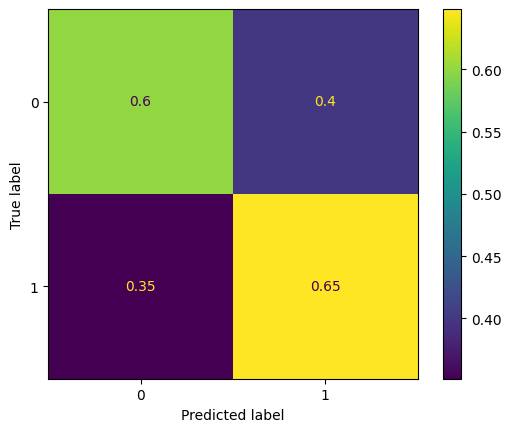

In [114]:


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize="true"
)

print(classification_report(y_test, y_pred))



### Ajuste de limiar de decisão

Como a saída do modelo é probabilística, o limiar de decisão pode ser
ajustado para priorizar o recall da classe positiva (atraso), de acordo
com objetivos operacionais.


In [115]:

threshold = 0.502
y_pred_threshold = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_threshold))


              precision    recall  f1-score   support

           0       0.86      0.61      0.72   4618024
           1       0.30      0.64      0.41   1221118

    accuracy                           0.62   5839142
   macro avg       0.58      0.63      0.56   5839142
weighted avg       0.75      0.62      0.65   5839142



<a name="calibracao"></a>
###Calibração do classificador para aumentar performance
[⬆️ Índice](#indice)

In [116]:
#Conjunto separado para calibração

X_calib = X_train_sampled.sample(n=300_000, random_state=42)
y_calib = y_train_sampled.loc[X_calib.index]



<a name="calibracao"></a>
Criação do modelo de Calibração (modelo já treinado)

In [117]:
calibrated_model = CalibratedClassifierCV(
    estimator=rf_model,
    method="sigmoid",
    cv="prefit"
)

Aplicando modelo de calibração

In [118]:
calibrated_model.fit(X_calib, y_calib)

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


CalibratedClassifierCV(cv='prefit',
                       estimator=Pipeline(steps=[('preprocess',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   'passthrough',
                                                                                   ['hour_bucket',
                                                                                    'day_of_week',
                                                                                    'month',
                                                                                    'is_peak_hour',
                                                                                    'is_weekend',
                                                                                    'is_holiday',
                                                                                    'is_long_weekend',
                                                                                    'wind_max_1h',
                                                                                    'cloud_mean_1h',
                                                                                    'rain_sum_1h',
                                                                                    'snow_sum_1h',
                                                                                    'cancel_rate_route_30d',
                                                                                    'cancel_rate_origin_30d',
                                                                                    'cancel_rate_airline_30d']),
                                                                                  ('cat',
                                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                                 max_categories=500,
                                                                                                 min_frequency=0.0005,
                                                                                                 sparse_output=False),
                                                                                   ['airline',
                                                                                    'route'])])),
                                                 ('model',
                                                  RandomForestClassifier(class_weight='balanced',
                                                                         max_depth=9,
                                                                         min_samples_leaf=200,
                                                                         min_samples_split=500,
                                                                         n_jobs=-1,
                                                                         random_state=42))]))

Avaliação da calibração !

In [119]:
proba = calibrated_model.predict_proba(X_test)[:, 1]

Avaliação do modelo calibrado

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


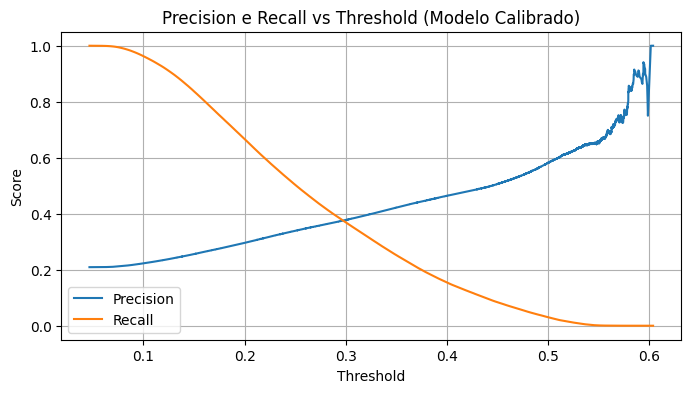

Melhor threshold (F1): 0.215
Precision: 0.309, Recall: 0.615, F1: 0.411

Relatório de Classificação com threshold ajustado:
              precision    recall  f1-score   support

  No horário       0.86      0.64      0.73   4618024
    Atrasado       0.31      0.61      0.41   1221118

    accuracy                           0.63   5839142
   macro avg       0.59      0.63      0.57   5839142
weighted avg       0.75      0.63      0.67   5839142



In [120]:

# 1) Probabilidades do MODELO CALIBRADO
y_proba = calibrated_model.predict_proba(X_test)[:, 1]

# 2) Curva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# 3) Plot
plt.figure(figsize=(8,4))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision e Recall vs Threshold (Modelo Calibrado)")
plt.legend()
plt.grid(True)
plt.show()

# 4) F1-score por threshold (evita divisão por zero)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (
    precisions[:-1] + recalls[:-1] + 1e-9
)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Melhor threshold (F1): {best_threshold:.3f}")
print(
    f"Precision: {precisions[best_idx]:.3f}, "
    f"Recall: {recalls[best_idx]:.3f}, "
    f"F1: {f1_scores[best_idx]:.3f}"
)

# 5) Avaliação final com threshold ótimo
y_pred_opt = (y_proba >= best_threshold).astype(int)

print("\nRelatório de Classificação com threshold ajustado:")
print(classification_report(
    y_test,
    y_pred_opt,
    target_names=["No horário", "Atrasado"]
))


<a name="artefato-final"></a>
## 14. Artefato Final e Uso do Modelo
[⬆️ Índice](#indice)

O artefato final do projeto consiste em um objeto serializado que encapsula o pipeline completo de Machine Learning, incluindo as etapas de pré-processamento, o modelo Random Forest treinado e o limiar de decisão (threshold) ajustado.

Essa abordagem garante que o mesmo fluxo utilizado durante o treinamento seja preservado no momento da inferência, evitando inconsistências entre ambiente de desenvolvimento e uso em produção.

O artefato permite que o modelo seja carregado e utilizado diretamente para gerar probabilidades de atraso e decisões finais de classificação, sem necessidade de reconfiguração manual.


In [121]:

artefato_modelo = {
    "pipeline": calibrated_model,
    "threshold": 0.215
}

joblib.dump(artefato_modelo, "artefato_atraso_voos_rf.joblib")


['artefato_atraso_voos_rf.joblib']

### Wrapper de Inferência

In [126]:
%%writefile wrapper.py
# model_wrapper.py
"""
Wrapper de inferência para o modelo de previsão de atraso de voos.

Este módulo encapsula:
- carregamento do artefato treinado (joblib)
- execução do pipeline de Machine Learning
- aplicação do threshold de decisão

O backend deve interagir EXCLUSIVAMENTE com a função `predict_voo`.
"""
from pathlib import Path
import joblib
import pandas as pd


# ============================================================
# Carregamento do artefato
# ============================================================

ARTEFATO_PATH = Path("artefato_atraso_voos_rf.joblib")

artefato = joblib.load(ARTEFATO_PATH)
modelo = artefato["pipeline"]
threshold = artefato["threshold"]

# ============================================================
# Função de inferência
# ============================================================

def previsao_voo(novo_voo: dict) -> dict:
    """
    Retorna a classe mais provável (0 = No horário, 1 = Atrasado)
    e a probabilidade associada em percentual.
    """

    entrada_voo = pd.DataFrame([novo_voo])

    prob_no_horario, prob_atrasado = modelo.predict_proba(entrada_voo)[0]

    if prob_atrasado > prob_no_horario:
        classe_prevista = 1
        probabilidade = prob_atrasado
    else:
        classe_prevista = 0
        probabilidade = prob_no_horario

    return {
        "prediction": classe_prevista,
        "probability": float(round(probabilidade * 100,2))
    }





Overwriting wrapper.py


In [127]:
import importlib
import wrapper
importlib.reload(wrapper)

from wrapper import previsao_voo


### Carregamento do Artefato

O artefato pode ser carregado em qualquer ambiente Python compatível, preservando tanto o pipeline treinado quanto o threshold definido na etapa de otimização.


In [128]:
# Carregando o artefato final

artefato = joblib.load("artefato_atraso_voos_rf.joblib")

modelo = artefato["pipeline"]
threshold = artefato["threshold"]


### Uso do Modelo para Inferência

Para realizar uma previsão, os dados de entrada devem seguir o mesmo formato utilizado durante o treinamento.  
O modelo retorna a probabilidade de atraso, e a decisão final é obtida aplicando o threshold armazenado no artefato.


In [129]:
from wrapper import previsao_voo

novo_voo = {
    "airline": "AAL",
    "route": "KMIA_SBGR",
    "hour_bucket": 2,
    "day_of_week": 4,
    "month": 7,
    "is_peak_hour": 1,
    "is_weekend": 0,
    "is_holiday": 0,
    "is_long_weekend": 0,
    "wind_max_1h": 12.5,
    "cloud_mean_1h": 85.0,
    "rain_sum_1h": 3.2,
    "snow_sum_1h": 0.0,
    "cancel_rate_route_30d": 0.25,
    "cancel_rate_origin_30d": 0.12,
    "cancel_rate_airline_30d": 0.18
}


previsao_voo(novo_voo)


{'prediction': 0, 'probability': 66.77}

### Considerações Finais

Ao encapsular o pipeline e o threshold em um único artefato, o modelo torna-se reutilizável, reprodutível e seguro para uso em produção.  
Essa estratégia garante consistência entre treinamento e inferência, além de facilitar integrações futuras com APIs ou sistemas de apoio à decisão.


## 15. Análise Crítica

O modelo desenvolvido apresentou desempenho consistente e estável, demonstrando boa capacidade de generalização ao ser avaliado em dados temporais futuros. A estratégia de separação temporal entre treino e teste evitou vazamento de informação, tornando a avaliação mais realista para um cenário de uso em produção.

A utilização de amostragem no conjunto de treino foi fundamental para viabilizar o treinamento do Random Forest em um conjunto de dados de grande escala. Os experimentos mostraram que o aumento do volume de dados além de um determinado ponto não resultou em ganhos significativos de desempenho, evidenciando a presença de retornos decrescentes e indicando que o modelo não se encontrava limitado por quantidade de dados.

O controle da dimensionalidade por meio do One-Hot Encoding com limitação de categorias permitiu manter as variáveis categóricas relevantes sem comprometer a viabilidade computacional. Essa decisão mostrou-se eficaz para preservar o sinal estatístico das rotas e companhias aéreas mais frequentes, ao mesmo tempo em que reduziu ruído proveniente de categorias raras.

Em relação às métricas, observou-se um trade-off claro entre precisão e recall na detecção de atrasos. O modelo apresentou maior sensibilidade à classe positiva, priorizando a identificação de voos com risco de atraso. Esse comportamento foi ajustado por meio do thresholding, que se mostrou uma etapa essencial para alinhar o modelo a diferentes objetivos de decisão, evidenciando que a otimização do critério de decisão pode ser tão relevante quanto o ajuste do próprio algoritmo.

Como limitação, destaca-se que o modelo depende fortemente da qualidade das variáveis históricas e climáticas utilizadas. Mudanças estruturais no comportamento operacional das companhias aéreas ou eventos atípicos não representados nos dados históricos podem impactar o desempenho do modelo. Além disso, o uso de Random Forest implica maior custo computacional quando comparado a modelos lineares, o que justifica as estratégias de regularização e amostragem adotadas.

De forma geral, o projeto atingiu seus objetivos ao construir um modelo preditivo robusto, interpretável e viável computacionalmente, com decisões técnicas fundamentadas em evidência empírica. O trabalho demonstra a importância de alinhar modelagem estatística, engenharia de dados e critérios de decisão para a construção de soluções de Machine Learning aplicáveis a problemas reais.


## 16. Limitações

Apesar dos bons resultados obtidos, o modelo apresenta algumas limitações que devem ser consideradas. A principal delas está relacionada à dependência de dados históricos: o desempenho do modelo pressupõe que padrões passados de atraso, clima e operação se mantenham relativamente estáveis ao longo do tempo. Mudanças estruturais no setor aéreo, como alterações regulatórias, crises operacionais ou eventos extremos não representados nos dados, podem reduzir a capacidade preditiva do modelo.

Outra limitação refere-se ao uso de amostragem no conjunto de treino. Embora a amostra tenha se mostrado representativa e estatisticamente consistente, o modelo não foi treinado com a totalidade dos dados disponíveis, o que pode limitar a captura de padrões muito raros. Ainda assim, testes indicaram retornos decrescentes com o aumento do volume de dados, justificando a escolha adotada.

O processo de One-Hot Encoding, mesmo controlado por limitação de frequência e número máximo de categorias, pode perder informação associada a rotas ou companhias pouco frequentes, que acabam sendo agregadas. Isso representa um trade-off entre viabilidade computacional e granularidade das variáveis categóricas.

Além disso, o modelo não incorpora informações operacionais em tempo real, como atrasos acumulados ao longo do dia, manutenção de aeronaves ou condições específicas de aeroportos no momento do voo. A ausência dessas variáveis pode limitar o desempenho em cenários altamente dinâmicos.

Por fim, o Random Forest, apesar de robusto e eficaz, apresenta maior custo computacional quando comparado a modelos mais simples, como regressões lineares. Isso exige cuidados adicionais para escalabilidade e pode restringir seu uso em ambientes com recursos computacionais limitados.


## 17. Possíveis Melhorias

Uma das principais oportunidades de melhoria do modelo está relacionada à disponibilidade de dados. O projeto foi desenvolvido sem acesso a informações sensíveis ou detalhadas dos aeroportos, como dados internos de operação, manutenção de aeronaves, alocação de equipes, congestionamento em solo ou priorização de slots. A inclusão desse tipo de informação poderia enriquecer significativamente o conjunto de variáveis explicativas e melhorar a capacidade preditiva do modelo.

Outra melhoria potencial seria a incorporação de dados operacionais em tempo real ou quase em tempo real, como atrasos acumulados ao longo do dia, condições atuais das pistas, eventos climáticos extremos imediatos ou interrupções operacionais. Esses dados permitiriam capturar dinâmicas que não estão totalmente representadas em janelas históricas ou médias temporais.

Do ponto de vista de modelagem, poderiam ser explorados algoritmos alternativos ou complementares ao Random Forest, como Gradient Boosting, XGBoost ou modelos baseados em LightGBM, que tendem a lidar melhor com grandes volumes de dados e podem apresentar melhor desempenho em cenários de alta complexidade. Além disso, técnicas de ensemble entre diferentes modelos poderiam ser avaliadas para aumentar a robustez das previsões.

Por fim, o processo de decisão poderia ser refinado por meio de thresholds dinâmicos, ajustados de acordo com diferentes contextos operacionais ou objetivos de negócio, como horários de pico, rotas críticas ou períodos de maior sensibilidade a atrasos. Essas melhorias permitiriam adaptar o modelo a cenários específicos, aumentando sua utilidade prática e flexibilidade.


<a name="conclusao"></a>
## 18. Conclusão
[⬆️ Índice](#indice)

Neste projeto, foi desenvolvido um modelo de Machine Learning para previsão de atrasos de voos, combinando dados temporais, climáticos e históricos operacionais. Ao longo do trabalho, foram aplicadas técnicas de engenharia de dados, controle de dimensionalidade e regularização de modelo, garantindo viabilidade computacional mesmo em um cenário de grande volume de dados.

A adoção de uma separação temporal entre treino e teste permitiu uma avaliação realista do desempenho do modelo, aproximando-o de um cenário de uso em produção. O uso de amostragem representativa mostrou-se uma estratégia eficaz para reduzir o custo computacional sem comprometer a qualidade das previsões, evidenciando que o modelo não estava limitado pela quantidade de dados, mas sim por sua estrutura e critério de decisão.

O Random Forest, aliado a um pré-processamento adequado e ao ajuste do limiar de classificação, apresentou um bom equilíbrio entre capacidade preditiva e estabilidade. A etapa de thresholding revelou-se fundamental para alinhar o comportamento do modelo aos objetivos do problema, destacando a importância de diferenciar a estimativa de probabilidades da tomada de decisão final.

Apesar das limitações inerentes à ausência de dados sensíveis e informações operacionais em tempo real, o modelo demonstrou potencial prático e robustez suficiente para aplicações de apoio à decisão no contexto aeroportuário. As possíveis melhorias identificadas apontam caminhos claros para evolução futura do trabalho, seja por meio da ampliação das fontes de dados, seja pela adoção de técnicas de modelagem mais avançadas.

De forma geral, o projeto alcançou seus objetivos ao entregar um artefato final consistente, reproduzível e aplicável, reforçando a importância da integração entre análise exploratória, engenharia de dados, modelagem estatística e critérios de decisão na construção de soluções de Data Science voltadas a problemas reais.
